# EDA 4 Rerun — Frame & Boundary Effects: London-Only vs National Frame - New geo harmonisation - 20260625

**Purpose:** Quantify how moving from a London-only analysis to a national frame changes the cascade–counter balance and the typology — and, crucially, *decompose* that change into its two distinct causes.

### Three frames
A naïve "London vs national" comparison conflates two separate things. We separate them with an intermediate frame **B**:

| Frame | Flows included | Decile ladder | Suffix |
|-------|----------------|---------------|--------|
| **A** | London-internal only | London-relative (983 MSOAs) | `_11` / `_21` |
| **B** | London-internal only | **National** (~6,800 MSOAs) | `_intnat_` |
| **C** | London-internal **+ external** | National | `_nat_` |

- **Reclassification effect = B − A** — same flows, different decile ladder.
- **External-flow effect = C − B** — same ladder, external flows added.
- **Total = C − A** — what a naïve comparison reports (and what the earlier draft attributed entirely to external flows).

### Scope 
*(Part 0 builds the three frames; Parts 1–4 below are the analysis.)*
1. **Part 1 — Where do external flows land?** Distribution across the hierarchy, the A/B/C decomposition of the churn "boost", and a three-way *flow-direction* decomposition (within-London / outside→London / London→outside).
2. **Part 2 — What shifts in the cascade–counter balance?** Every London-vs-national comparison split into reclassification vs external.
3. **Part 3 — Does the typology change?** Typology under all three frames; switches attributed directly to reclassification (A→B) vs external flows (B→C).
4. **Part 4 — Which MSOAs are extreme?** The most cascade- and counter-dominant MSOAs, both years, both frames.

Attribute-based profiling (tenure, occupational class, prices) is **deferred to the next notebook**, which consumes the results table exported at the end here.

### Data source
`msoa_cascade_national_frame_20260625.csv` — 983 London MSOAs with London-only (`_11`/`_21`) and national-frame (`_nat_`) cascade metrics.

---


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
from pyprojroot import here

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# ── Paths ────────────────────────
ROOT = here()
DATA_DIR = ROOT / 'outputs'
OUTPUT_DIR = ROOT / 'outputs/rerun_eda_figs_20260625'
GEO_PATH = ROOT / 'data/london_msoa_2011.geojson'


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [36]:
# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'msoa_cascade_national_frame_20260625.csv')
print(f'Loaded: {df.shape[0]} MSOAs, {df.shape[1]} columns')

# Quick check: national columns present
nat_cols = [c for c in df.columns if '_nat_' in c]
print(f'National-frame columns: {len(nat_cols)}')

Loaded: 982 MSOAs, 98 columns
National-frame columns: 36


---
# PART 0: Setup — Constructing the Three Frames

Before any analysis we assemble the three comparison frames. **0a** computes the national-frame derived metrics the preprocessing did not export; **0b** constructs **Frame B** (London-internal flows on the national ladder) — the middle term that lets Parts 1–4 separate the *reclassification* effect (B − A) from the *external-flow* effect (C − B).


## 0a. Compute Missing National-Frame Derived Metrics

The preprocessing exported base metrics and `Cascade_Dominance_nat`, but not:
- `Cross_Decile_Share_nat` — share of migration crossing decile boundaries among all migration records.
- `Sign_Concordance_nat` — whether Net_Cascade and Net_Counter share the same sign.

We compute these here using the same formulas as EDA 1.

In [37]:
# ── Cross_Decile_Share_nat ────────────────────────────────────
# Formula: (CFI_Churn + Counter_Churn) / Total_Migration
for yr in ['11', '21']:
    cfi  = df[f'CFI_Churn_nat_{yr}']
    cc   = df[f'Counter_Churn_nat_{yr}']
    tmig = df[f'Total_Migration_nat_{yr}']
    df[f'Cross_Decile_Share_nat_{yr}'] = np.where(
        tmig > 0, (cfi + cc) / tmig, 0)

# ── Sign_Concordance_nat ──────────────────────────────────────
for yr in ['11', '21']:
    nc  = df[f'Net_Cascade_nat_{yr}']
    ncc = df[f'Net_Counter_nat_{yr}']
    df[f'Sign_Concordance_nat_{yr}'] = np.where(
        (nc == 0) | (ncc == 0), 'zero',
        np.where(np.sign(nc) == np.sign(ncc), 'concordant', 'divergent')
    )

# ── Verify ────────────────────────────────────────────────────
print('=== Cross_Decile_Share_nat (2011) ===')
print(df['Cross_Decile_Share_nat_11'].describe().round(4).to_string())
print(f'\n=== Sign_Concordance_nat (2011) ===')
print(df['Sign_Concordance_nat_11'].value_counts().to_string())

print(f'\n=== Cross_Decile_Share_nat (2021) ===')
print(df['Cross_Decile_Share_nat_21'].describe().round(4).to_string())
print(f'\n=== Sign_Concordance_nat (2021) ===')
print(df['Sign_Concordance_nat_21'].value_counts().to_string())

=== Cross_Decile_Share_nat (2011) ===
count    982.0000
mean       0.8227
std        0.1031
min        0.5183
25%        0.7522
50%        0.8434
75%        0.9055
max        0.9957

=== Sign_Concordance_nat (2011) ===
Sign_Concordance_nat_11
concordant    903
divergent      78
zero            1

=== Cross_Decile_Share_nat (2021) ===
count    982.0000
mean       0.8350
std        0.0985
min        0.4879
25%        0.7754
50%        0.8540
75%        0.9119
max        0.9991

=== Sign_Concordance_nat (2021) ===
Sign_Concordance_nat_21
concordant    855
divergent     126
zero            1


### Interpretation:

- Count of 982, rerun both data preprocess file with sufix 20260625, 2021 MSOA codes map with 2011 ones, not just picking unchanged, but also dealing with splitting and merging ones.

> **Why there is a single "Zero" sign concordance in both periods? Are they the same one? Where are they?** (Uncovered below)

In [38]:
for yr in ['11','21']:
    z = df[df[f'Sign_Concordance_nat_{yr}'] == 'zero']
    for _, r in z.iterrows():
        nc, ncc, tm = (r[f'Net_Cascade_nat_{yr}'], r[f'Net_Counter_nat_{yr}'],
                       r[f'Total_Migration_nat_{yr}'])
        kind = ('no_data (no migration)' if tm == 0
                else 'balanced (both nets exactly 0)' if nc == 0 and ncc == 0
                else 'partial (one net exactly 0)')
        print(f"20{yr}: {r['msoa11cd']} {r['ladnm']} D{r['Wealth_Decile_National']:.0f} | "
              f"Net_Cascade={nc:+.0f}  Net_Counter={ncc:+.0f}  TotMig={tm:.0f}  -> {kind}")

2011: E02000104 Brent D4 | Net_Cascade=+0  Net_Counter=+85  TotMig=1454  -> partial (one net exactly 0)
2021: E02000758 Redbridge D5 | Net_Cascade=+0  Net_Counter=+87  TotMig=852  -> partial (one net exactly 0)


### Single "Zero" in both periods Interpretation

"Zero" means whenever `Net_Cascade` or `Net_Counter` is 0. Since zero is neither positive or negative, it can't be labelled as concordant or divergent.

"Zero" in 2011 and 2021 are not the same. This is a knife-edge coincidence that lands on different MSOAs in different periods.
- In Brent, national D4, in 2011:
    - Its cascade legs cancel exactly
    - Net_Counter = 85, which is non-zero; and total_migration is 1454 
- In Redbridge, national D5, in 2021:
    - In the pre-fix data, both (Brexley and Redbridge) land on 0 in 2021
    -  After the fix reconnected the recovered flows, one of them shifted off zero, leaving the single one here.

## 0b. Construct Frame B — Internal Flows on the National Ladder

Frame A (London ladder) and Frame C (national ladder + external flows) already live in the data. Frame **B** — London-internal flows scored on the *national* ladder — is the missing middle term that lets us separate the **reclassification** effect (ladder switch) from the **external-flow** effect.

We derive B from C by removing the external contributions. For an MSOA with national decile *d* and the synthetic external node fixed at D6:
- *d* < 6 → external inflow is `Inflow_Wealthier`, external outflow is `Outflow_Wealthier`
- *d* > 6 → external inflow is `Inflow_Poorer`, external outflow is `Outflow_Poorer`
- *d* = 6 → external flows are lateral (no cascade/counter effect)

Subtracting those gives internal-only flows on the national ladder. **B's total migration must equal A's exactly** (identical internal flows) — checked below. The suffix `_intnat_` = *internal flows, national deciles*.


In [39]:
# ── Frame B: internal London flows scored on the NATIONAL ladder ──────────
EXT_DECILE = 6                       # synthetic external MSOA assigned D6

df = df.copy()

nat_dec = df['Wealth_Decile_National']

for yr in ['11', '21']:
    ext_in  = df[f'Ext_Inflow_nat_{yr}'].fillna(0)
    ext_out = df[f'Ext_Outflow_nat_{yr}'].fillna(0)

    ext_to_iw = np.where(nat_dec < EXT_DECILE, ext_in, 0)   # Inflow_Wealthier
    ext_to_ip = np.where(nat_dec > EXT_DECILE, ext_in, 0)   # Inflow_Poorer
    ext_to_ow = np.where(nat_dec < EXT_DECILE, ext_out, 0)  # Outflow_Wealthier
    ext_to_op = np.where(nat_dec > EXT_DECILE, ext_out, 0)  # Outflow_Poorer

    # B = C minus external contribution
    df[f'Inflow_Wealthier_intnat_{yr}']  = df[f'Inflow_Wealthier_nat_{yr}']  - ext_to_iw
    df[f'Outflow_Poorer_intnat_{yr}']    = df[f'Outflow_Poorer_nat_{yr}']    - ext_to_op
    df[f'Outflow_Wealthier_intnat_{yr}'] = df[f'Outflow_Wealthier_nat_{yr}'] - ext_to_ow
    df[f'Inflow_Poorer_intnat_{yr}']     = df[f'Inflow_Poorer_nat_{yr}']     - ext_to_ip

    df[f'CFI_Churn_intnat_{yr}']     = (df[f'Inflow_Wealthier_intnat_{yr}'] +
                                        df[f'Outflow_Poorer_intnat_{yr}'])
    df[f'Counter_Churn_intnat_{yr}'] = (df[f'Outflow_Wealthier_intnat_{yr}'] +
                                        df[f'Inflow_Poorer_intnat_{yr}'])
    df[f'Net_Cascade_intnat_{yr}']   = (df[f'Inflow_Wealthier_intnat_{yr}'] -
                                        df[f'Outflow_Poorer_intnat_{yr}'])
    df[f'Net_Counter_intnat_{yr}']   = (df[f'Outflow_Wealthier_intnat_{yr}'] -
                                        df[f'Inflow_Poorer_intnat_{yr}'])

    total_cross_b = df[f'CFI_Churn_intnat_{yr}'] + df[f'Counter_Churn_intnat_{yr}']
    df[f'Cascade_Dominance_intnat_{yr}'] = np.where(
        total_cross_b > 0, df[f'CFI_Churn_intnat_{yr}'] / total_cross_b, 0.5)

    df[f'Total_Migration_intnat_{yr}'] = (df[f'Total_Migration_nat_{yr}']
                                          - ext_in - ext_out)
    df[f'Cross_Decile_Share_intnat_{yr}'] = np.where(
        df[f'Total_Migration_intnat_{yr}'] > 0,
        total_cross_b / df[f'Total_Migration_intnat_{yr}'], 0)

    # Sign concordance for Frame B (same rule as A and C)
    nc, ncc = df[f'Net_Cascade_intnat_{yr}'], df[f'Net_Counter_intnat_{yr}']
    df[f'Sign_Concordance_intnat_{yr}'] = np.where(
        (nc == 0) | (ncc == 0), 'zero',
        np.where(np.sign(nc) == np.sign(ncc), 'concordant', 'divergent'))

# ── Sanity checks ─────────────────────────────────────────────────────────
print('=' * 70)
print('FRAME B SANITY CHECKS  (suffix _intnat_ = internal flows, national deciles)')
print('=' * 70)
for yr in ['11', '21']:
    diff = (df[f'Total_Migration_intnat_{yr}'] - df[f'Total_Migration_{yr}']).abs().max()
    neg = min(df[f'Inflow_Wealthier_intnat_{yr}'].min(), df[f'Outflow_Poorer_intnat_{yr}'].min(),
              df[f'Outflow_Wealthier_intnat_{yr}'].min(), df[f'Inflow_Poorer_intnat_{yr}'].min())
    print(f'\n  20{yr}:')
    print(f'    Total_Migration  B vs A  max diff : {diff:.1f}   (should be 0)')
    print(f'    Min base flow in B               : {neg:.0f}   (should be >= 0)')
    print(f'    Mean Cascade_Dominance  A={df[f"Cascade_Dominance_{yr}"].mean():.4f}  '
          f'B={df[f"Cascade_Dominance_intnat_{yr}"].mean():.4f}  '
          f'C={df[f"Cascade_Dominance_nat_{yr}"].mean():.4f}')
print('\nFrame B constructed.')


FRAME B SANITY CHECKS  (suffix _intnat_ = internal flows, national deciles)

  2011:
    Total_Migration  B vs A  max diff : 0.0   (should be 0)
    Min base flow in B               : 0   (should be >= 0)
    Mean Cascade_Dominance  A=0.4796  B=0.4814  C=0.4862

  2021:
    Total_Migration  B vs A  max diff : 0.0   (should be 0)
    Min base flow in B               : 0   (should be >= 0)
    Mean Cascade_Dominance  A=0.4644  B=0.4654  C=0.4551

Frame B constructed.


### Interpretation:

***No matter with which frame (ladder and flow compositions), Cascade_Dominance is always below 0.5.***


In [40]:
# ── Diagnostic: zero cross-decile-share / zero-migration MSOAs ────────────
print('=' * 70)
print('DIAGNOSTIC: zero-CDS / zero-migration MSOAs (exist identically in both frames)')
print('=' * 70)
for yr in ['11', '21']:
    nat_zero = set(df.loc[df[f'Cross_Decile_Share_nat_{yr}'] == 0, 'msoa11cd'])
    ldn_zero = set(df.loc[df[f'Cross_Decile_Share_{yr}'] == 0, 'msoa11cd'])
    print(f'\n  20{yr}:  National CDS=0: {len(nat_zero):>3d}   London CDS=0: {len(ldn_zero):>3d}'
          f'   identical set? {nat_zero == ldn_zero}')
    if nat_zero:
        m = df['msoa11cd'].isin(nat_zero)
        print(f'    all Total_Mig_nat=0? {(df.loc[m, f"Total_Migration_nat_{yr}"] == 0).all()}'
              f'   all Ext_Inflow=0? {(df.loc[m, f"Ext_Inflow_nat_{yr}"] == 0).all()}')

# ── Suppression flag: zero-migration MSOAs are disclosure artefacts ───────
# (diagnosed in EDA2/EDA3 as small-cell disclosure control, not real zeros)
for yr in ['11', '21']:
    df[f'Suppressed_{yr}'] = df[f'Total_Migration_nat_{yr}'] == 0
VALID = {yr: ~df[f'Suppressed_{yr}'] for yr in ['11', '21']}
print(f'\nSuppression flag set:  2011 -> {int(df["Suppressed_11"].sum())} MSOAs   '
      f'2021 -> {int(df["Suppressed_21"].sum())} MSOAs')
print('Policy: these are EXCLUDED from 2021 thresholds, means, typology counts and')
print("correlations, and labelled 'Suppressed' (not 'Lateral') in the typology.")
print('Valid N:  2011 =', int(VALID['11'].sum()), '  2021 =', int(VALID['21'].sum()))


DIAGNOSTIC: zero-CDS / zero-migration MSOAs (exist identically in both frames)

  2011:  National CDS=0:   0   London CDS=0:   0   identical set? True

  2021:  National CDS=0:   0   London CDS=0:   0   identical set? True

Suppression flag set:  2011 -> 0 MSOAs   2021 -> 0 MSOAs
Policy: these are EXCLUDED from 2021 thresholds, means, typology counts and
correlations, and labelled 'Suppressed' (not 'Lateral') in the typology.
Valid N:  2011 = 982   2021 = 982


---
# PART 1: Where Do External Flows Land?

External flows connect London MSOAs to the synthetic `EXT_OUTSIDE` MSOA (assigned national D6). Because ~69% of London MSOAs sit in national D1–D5, for those areas external inflows are `Inflow_Wealthier` and external outflows are `Outflow_Wealthier`.

This section quantifies:
- Aggregate external flow volumes (2011 vs 2021)
- How external inflows and outflows distribute across the decile hierarchy
- Which MSOAs receive the largest external flow injections

---

## 1a. Aggregate External Flow Summary

In [41]:
print('=' * 65)
print('AGGREGATE EXTERNAL FLOW SUMMARY')
print('=' * 65)

for yr in ['11', '21']:
    ei = df[f'Ext_Inflow_nat_{yr}']
    eo = df[f'Ext_Outflow_nat_{yr}']
    en = df[f'Ext_Net_nat_{yr}']
    
    print(f'\n── 20{yr} ──')
    print(f'  External inflows  (Ext→Ldn):  {ei.sum():>10,.0f} total, '
          f'{ei.mean():>6.1f} per MSOA')
    print(f'  External outflows (Ldn→Ext):  {eo.sum():>10,.0f} total, '
          f'{eo.mean():>6.1f} per MSOA')
    print(f'  Net external:                 {en.sum():>10,.0f} total, '
          f'{en.mean():>+6.1f} per MSOA')
    print(f'  London is a net {"EXPORTER" if en.sum() < 0 else "IMPORTER"} '
          f'of {abs(en.sum()):,.0f} migrants')
    print(f'  MSOAs with zero external flows: {(ei == 0).sum()}')

# Temporal change
ei_11, ei_21 = df['Ext_Inflow_nat_11'].sum(), df['Ext_Inflow_nat_21'].sum()
eo_11, eo_21 = df['Ext_Outflow_nat_11'].sum(), df['Ext_Outflow_nat_21'].sum()
print(f'\n── Temporal Change ──')
print(f'  Inflow change:  {ei_21 - ei_11:>+10,.0f}  ({(ei_21/ei_11 - 1)*100:>+.1f}%)')
print(f'  Outflow change: {eo_21 - eo_11:>+10,.0f}  ({(eo_21/eo_11 - 1)*100:>+.1f}%)')
print(f'  ⟹ External outflow nearly {eo_21/eo_11:.1f}x the 2011 level')

AGGREGATE EXTERNAL FLOW SUMMARY

── 2011 ──
  External inflows  (Ext→Ldn):     187,595 total,  191.0 per MSOA
  External outflows (Ldn→Ext):     219,221 total,  223.2 per MSOA
  Net external:                    -31,626 total,  -32.2 per MSOA
  London is a net EXPORTER of 31,626 migrants
  MSOAs with zero external flows: 0

── 2021 ──
  External inflows  (Ext→Ldn):     154,172 total,  157.0 per MSOA
  External outflows (Ldn→Ext):     331,600 total,  337.7 per MSOA
  Net external:                   -177,428 total, -180.7 per MSOA
  London is a net EXPORTER of 177,428 migrants
  MSOAs with zero external flows: 0

── Temporal Change ──
  Inflow change:     -33,423  (-17.8%)
  Outflow change:   +112,379  (+51.3%)
  ⟹ External outflow nearly 1.5x the 2011 level


### Interpretation:

***London became a more net exporter by 2021 from 2011, with less external inflows(-17.8%) and huge increase in external outflows (+51.3%).***

## 1b. How External Flows Are Classified, given the external is fixed as D6

The synthetic external MSOA is assigned national D6. 

For each London MSOA, whether the external flow counts as "wealthier" or "poorer" depends on that MSOA's own national decile. 

This table shows the classification logic directly.

In [42]:
EXT_DECILE = 6  # synthetic external MSOA assigned D6

print('=' * 72)
print('HOW EXTERNAL FLOWS ARE CLASSIFIED')
print('=' * 72)
print(f'\n  External MSOA decile: D{EXT_DECILE}')
print(f'  Convention: D1 = most deprived, D10 = least deprived\n')
print(f'{"Nat Decile":>10s} {"N MSOAs":>8s} {"Ext inflow is":>18s} {"Ext outflow is":>18s}')
print('-' * 58)

for d in range(1, 11):
    n = (df['Wealth_Decile_National'] == d).sum()
    if d < EXT_DECILE:
        inflow_type  = 'Inflow_Wealthier'
        outflow_type = 'Outflow_Wealthier'
    elif d > EXT_DECILE:
        inflow_type  = 'Inflow_Poorer'
        outflow_type = 'Outflow_Poorer'
    else:
        inflow_type  = 'LATERAL (same)'
        outflow_type = 'LATERAL (same)'
    print(f'  D{d:>2d}     {n:>5d}     {inflow_type:<18s} {outflow_type:<18s}')

below = (df['Wealth_Decile_National'] < EXT_DECILE).sum()
same  = (df['Wealth_Decile_National'] == EXT_DECILE).sum()
above = (df['Wealth_Decile_National'] > EXT_DECILE).sum()
print(f'\n  Summary:')
print(f'    D1–D5 (below D6): {below} MSOAs ({below/len(df)*100:.1f}%) '
      f'→ external = WEALTHIER connection')
print(f'    D6 (same):        {same} MSOAs ({same/len(df)*100:.1f}%) '
      f'→ external = LATERAL (no cascade effect)')
print(f'    D7–D10 (above):   {above} MSOAs ({above/len(df)*100:.1f}%) '
      f'→ external = POORER connection')

HOW EXTERNAL FLOWS ARE CLASSIFIED

  External MSOA decile: D6
  Convention: D1 = most deprived, D10 = least deprived

Nat Decile  N MSOAs      Ext inflow is     Ext outflow is
----------------------------------------------------------
  D 1       107     Inflow_Wealthier   Outflow_Wealthier 
  D 2       182     Inflow_Wealthier   Outflow_Wealthier 
  D 3       148     Inflow_Wealthier   Outflow_Wealthier 
  D 4       135     Inflow_Wealthier   Outflow_Wealthier 
  D 5       107     Inflow_Wealthier   Outflow_Wealthier 
  D 6        76     LATERAL (same)     LATERAL (same)    
  D 7        74     Inflow_Poorer      Outflow_Poorer    
  D 8        65     Inflow_Poorer      Outflow_Poorer    
  D 9        52     Inflow_Poorer      Outflow_Poorer    
  D10        36     Inflow_Poorer      Outflow_Poorer    

  Summary:
    D1–D5 (below D6): 679 MSOAs (69.1%) → external = WEALTHIER connection
    D6 (same):        76 MSOAs (7.7%) → external = LATERAL (no cascade effect)
    D7–D10 (above): 

> **Why this table is identical for both years.(we use the same result to represent for both periods)** 
>
> It depends only on each MSOA's national decile (fixed, from IMD 2010) and the external node's decile (fixed at D6) — neither changes across census years. Section 1b defines the *rules*; the volume flowing through each rule changes year-to-year, which 1c–1d quantify.

<!-- The majority of flows are `Outflow_Wealthier` — D1–D5 London MSOAs sending residents to the (D6-classified) external node. -->


In [43]:
def external_direction_split(df, yr):
    d, ein, eout = df['Wealth_Decile_National'], df[f'Ext_Inflow_nat_{yr}'], df[f'Ext_Outflow_nat_{yr}']
    below, same, above = d < EXT_DECILE, d == EXT_DECILE, d > EXT_DECILE
    s = pd.Series({
        'Inflow_Wealthier  (Ext→D1–D5)':  ein[below].sum(),
        'Outflow_Wealthier (D1–D5→Ext)':  eout[below].sum(),
        'Inflow_Poorer     (Ext→D7–D10)': ein[above].sum(),
        'Outflow_Poorer    (D7–D10→Ext)': eout[above].sum(),
        'Lateral inflow    (Ext→D6)':     ein[same].sum(),
        'Lateral outflow   (D6→Ext)':     eout[same].sum()}, dtype=float)
    return pd.DataFrame({'persons': s.round().astype(int), 'pct_of_external': (s/s.sum()*100).round(1)})

def external_by_decile(df, yr):
    g = df.groupby('Wealth_Decile_National').agg(
            N_MSOAs=('msoa11cd','size'),
            Ext_Inflow=(f'Ext_Inflow_nat_{yr}','sum'),
            Ext_Outflow=(f'Ext_Outflow_nat_{yr}','sum')).reset_index().rename(columns={'Wealth_Decile_National':'D'})
    g['inflow_is']  = np.where(g.D<EXT_DECILE,'Inflow_Wealthier',  np.where(g.D>EXT_DECILE,'Inflow_Poorer','Lateral'))
    g['outflow_is'] = np.where(g.D<EXT_DECILE,'Outflow_Wealthier', np.where(g.D>EXT_DECILE,'Outflow_Poorer','Lateral'))
    g['Ext_Net'] = g.Ext_Inflow - g.Ext_Outflow
    return g

for yr in ['11','21']:
    sp = external_direction_split(df, yr)
    print(f"\n=== 20{yr} ===\n", sp.to_string())
    print("  external as wealthier total:", sp[sp.index.str.contains('Wealthier')]['pct_of_external'].sum(), "%")
    print(external_by_decile(df, yr).to_string(index=False))


=== 2011 ===
                                 persons  pct_of_external
Inflow_Wealthier  (Ext→D1–D5)    132756             32.6
Outflow_Wealthier (D1–D5→Ext)    141153             34.7
Inflow_Poorer     (Ext→D7–D10)    40267              9.9
Outflow_Poorer    (D7–D10→Ext)    58487             14.4
Lateral inflow    (Ext→D6)        14572              3.6
Lateral outflow   (D6→Ext)        19581              4.8
  external as wealthier total: 67.30000000000001 %
 D  N_MSOAs  Ext_Inflow  Ext_Outflow        inflow_is        outflow_is  Ext_Net
 1      107       19297        18265 Inflow_Wealthier Outflow_Wealthier     1032
 2      182       32990        34154 Inflow_Wealthier Outflow_Wealthier    -1164
 3      148       30943        32394 Inflow_Wealthier Outflow_Wealthier    -1451
 4      135       27985        30956 Inflow_Wealthier Outflow_Wealthier    -2971
 5      107       21541        25384 Inflow_Wealthier Outflow_Wealthier    -3843
 6       76       14572        19581          Lat

### Interpretation:

***Over the census periods, there are more external flows in both direction from every deciles.*** ---> **people are attracted by moving outside London, even there are sitll a small proportion of people are moving into London, but the moving-in number has been decreased by 2021. (volume detail by decile below in 1c)**
- D1 attracted more external inflows in 2011, but it became more outflow dominated by 2021.
- All rest of deciles are external outflows dominated in 2011, and got intensified by 2021.
-  No matter external is defined as wealthier or poorer, there are always decreases in inflows from external and increases in outflows to external.
- Net external flows are all negative by 2021, consistent with more external outflows at every decile.
    - Among these negative changes, only D1 converted from positive at 2011, while all rest of deciles became significantly more negative.
    - The net external flows decreased (negative) relatively less only in D10, while for other deciles, the negative became stringly much more negative.


## 1c. External Flow Volumes by National Decile

In [44]:
# ── Table: external inflow & outflow by decile ────────────────
print('=' * 80)
print('EXTERNAL FLOW VOLUMES BY NATIONAL DECILE')
print('=' * 80)

dec_col = 'Wealth_Decile_National'
rows = []
for d in range(1, 11):
    mask = df[dec_col] == d
    row = {'Decile': d, 'N': mask.sum()}
    for yr in ['11', '21']:
        row[f'Ext_In_{yr}']  = df.loc[mask, f'Ext_Inflow_nat_{yr}'].sum()
        row[f'Ext_Out_{yr}'] = df.loc[mask, f'Ext_Outflow_nat_{yr}'].sum()
        row[f'Ext_Net_{yr}'] = df.loc[mask, f'Ext_Net_nat_{yr}'].sum()
    rows.append(row)

ext_dec = pd.DataFrame(rows)

print(f'\n{"Decile":>6s} {"N":>5s}  '
      f'{"Ext_In_11":>10s} {"Ext_Out_11":>10s} {"Ext_Net_11":>10s}  '
      f'{"Ext_In_21":>10s} {"Ext_Out_21":>10s} {"Ext_Net_21":>10s}')
print('-' * 80)
for _, r in ext_dec.iterrows():
    print(f'  D{r["Decile"]:>2.0f}  {r["N"]:>4.0f}  '
          f'{r["Ext_In_11"]:>10,.0f} {r["Ext_Out_11"]:>10,.0f} {r["Ext_Net_11"]:>+10,.0f}  '
          f'{r["Ext_In_21"]:>10,.0f} {r["Ext_Out_21"]:>10,.0f} {r["Ext_Net_21"]:>+10,.0f}')
print('-' * 80)
print(f'  Total {len(df):>4d}  '
      f'{ext_dec["Ext_In_11"].sum():>10,.0f} {ext_dec["Ext_Out_11"].sum():>10,.0f} '
      f'{ext_dec["Ext_Net_11"].sum():>+10,.0f}  '
      f'{ext_dec["Ext_In_21"].sum():>10,.0f} {ext_dec["Ext_Out_21"].sum():>10,.0f} '
      f'{ext_dec["Ext_Net_21"].sum():>+10,.0f}')

EXTERNAL FLOW VOLUMES BY NATIONAL DECILE

Decile     N   Ext_In_11 Ext_Out_11 Ext_Net_11   Ext_In_21 Ext_Out_21 Ext_Net_21
--------------------------------------------------------------------------------
  D 1   107      19,297     18,265     +1,032      17,078     32,012    -14,934
  D 2   182      32,990     34,154     -1,164      28,865     57,854    -28,989
  D 3   148      30,943     32,394     -1,451      26,088     52,261    -26,173
  D 4   135      27,985     30,956     -2,971      23,225     47,632    -24,407
  D 5   107      21,541     25,384     -3,843      17,194     37,131    -19,937
  D 6    76      14,572     19,581     -5,009      11,219     26,905    -15,686
  D 7    74      13,322     18,627     -5,305      10,288     25,369    -15,081
  D 8    65      13,914     18,191     -4,277       9,836     23,752    -13,916
  D 9    52       7,629     12,714     -5,085       6,036     16,904    -10,868
  D10    36       5,402      8,955     -3,553       4,343     11,780     -7,

In [45]:
# ------ duplicate results in 1b ------
# Showing percentages of London-external migration classification, 
# given external node is D6.

for yr in ['11', '21']:
    below = ext_dec['Decile'] < 6
    above = ext_dec['Decile'] > 6
    split = {
        'Outflow_Wealthier (D1–D5→Ext)':  ext_dec.loc[below, f'Ext_Out_{yr}'].sum(),
        'Inflow_Wealthier  (Ext→D1–D5)':  ext_dec.loc[below, f'Ext_In_{yr}'].sum(),
        'Outflow_Poorer    (D7–D10→Ext)': ext_dec.loc[above, f'Ext_Out_{yr}'].sum(),
        'Inflow_Poorer     (Ext→D7–D10)': ext_dec.loc[above, f'Ext_In_{yr}'].sum(),
    }
    tot = ext_dec[f'Ext_In_{yr}'].sum() + ext_dec[f'Ext_Out_{yr}'].sum()
    print(f"\n20{yr}:")
    for k, v in sorted(split.items(), key=lambda x: -x[1]):
        print(f"  {k:32s} {v:>9,.0f}  ({v/tot*100:4.1f}%)")


2011:
  Outflow_Wealthier (D1–D5→Ext)      141,153  (34.7%)
  Inflow_Wealthier  (Ext→D1–D5)      132,756  (32.6%)
  Outflow_Poorer    (D7–D10→Ext)      58,487  (14.4%)
  Inflow_Poorer     (Ext→D7–D10)      40,267  ( 9.9%)

2021:
  Outflow_Wealthier (D1–D5→Ext)      226,890  (46.7%)
  Inflow_Wealthier  (Ext→D1–D5)      112,450  (23.1%)
  Outflow_Poorer    (D7–D10→Ext)      77,805  (16.0%)
  Inflow_Poorer     (Ext→D7–D10)      30,503  ( 6.3%)


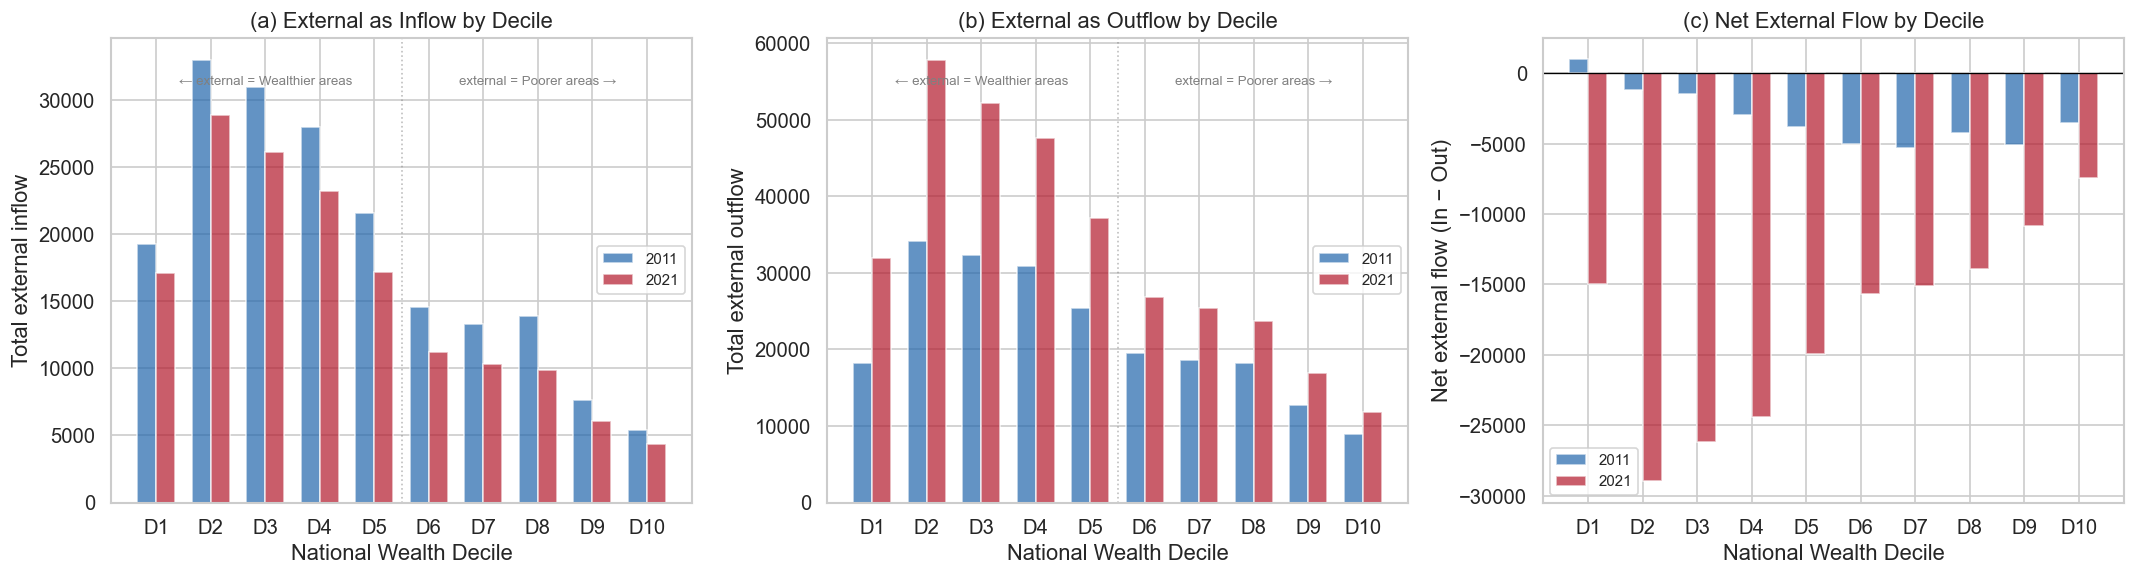

In [46]:
### NEED REFINE
### external is assigned as D6, 
### can it be shown as a vertical line between D5 and D6, meaning the external split?

# ── Fig 18: External flow volumes by decile ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(1, 11)
w = 0.35

# Panel (a): External inflow by decile
ax = axes[0]
ax.bar(x - w/2, ext_dec['Ext_In_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_In_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Total external inflow')
ax.set_title('(a) External as Inflow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.axvline(5.5, color='grey', ls=':', lw=1, alpha=0.5)
ax.text(3, ax.get_ylim()[1]*0.9, '← external = Wealthier areas', ha='center', fontsize=8, color='grey')
ax.text(8, ax.get_ylim()[1]*0.9, 'external = Poorer areas →', ha='center', fontsize=8, color='grey')
ax.legend(fontsize=9)

# Panel (b): External outflow by decile
ax = axes[1]
ax.bar(x - w/2, ext_dec['Ext_Out_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_Out_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Total external outflow')
ax.set_title('(b) External as Outflow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.axvline(5.5, color='grey', ls=':', lw=1, alpha=0.5)
ax.text(3, ax.get_ylim()[1]*0.9, '← external = Wealthier areas', ha='center', fontsize=8, color='grey')
ax.text(8, ax.get_ylim()[1]*0.9, 'external = Poorer areas →', ha='center', fontsize=8, color='grey')
ax.legend(fontsize=9)

# Panel (c): Net external by decile
ax = axes[2]
ax.bar(x - w/2, ext_dec['Ext_Net_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_Net_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Net external flow (In − Out)')
ax.set_title('(c) Net External Flow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.legend(fontsize=9)

# fig.suptitle('Fig 18: External Flow Volumes by National Wealth Decile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_18_external_flows_by_decile.png', dpi=150)
plt.show()

### Fig 18 Interpretation

Both bar plots of external inflows and outflows are right skewed, meaning the majority of both external flows are interacted between more deprived London MSOAs and outside London areas.

- In the plot external as inflows, there are clearly decrease almost for every decile from 2011 to 2021.
- In the plot external as outflows, there are certain increases for every decile by 2021, mainly focusing on D2 to D4.

But outflows from London to outside London increased significantly from 2011 to 2021, especially for London MSOAs in D2-D4. This showed more straightforward in the 3rd bar plot.

## 1d. Per-MSOA External Flow Intensity

**How large are external flows relative to total migration?** 

This determines how much leverage boundary effects have on each MSOA's cascade metrics.

In [47]:
# ── External share of total migration ─────────────────────────
for yr in ['11', '21']:
    ext_total = df[f'Ext_Inflow_nat_{yr}'] + df[f'Ext_Outflow_nat_{yr}']
    tmig = df[f'Total_Migration_nat_{yr}']
    df[f'Ext_Share_{yr}'] = np.where(tmig > 0, ext_total / tmig * 100, 0)

print('=== External flows as % of total migration ===')
for yr in ['11', '21']:
    col = f'Ext_Share_{yr}'
    print(f'\n  20{yr}:')
    print(f'    Mean:   {df[col].mean():.1f}%')
    print(f'    Median: {df[col].median():.1f}%')
    print(f'    P90:    {df[col].quantile(0.90):.1f}%')
    print(f'    Max:    {df[col].max():.1f}%')

=== External flows as % of total migration ===

  2011:
    Mean:   21.3%
    Median: 20.2%
    P90:    29.9%
    Max:    47.9%

  2021:
    Mean:   25.0%
    Median: 24.1%
    P90:    34.1%
    Max:    50.0%


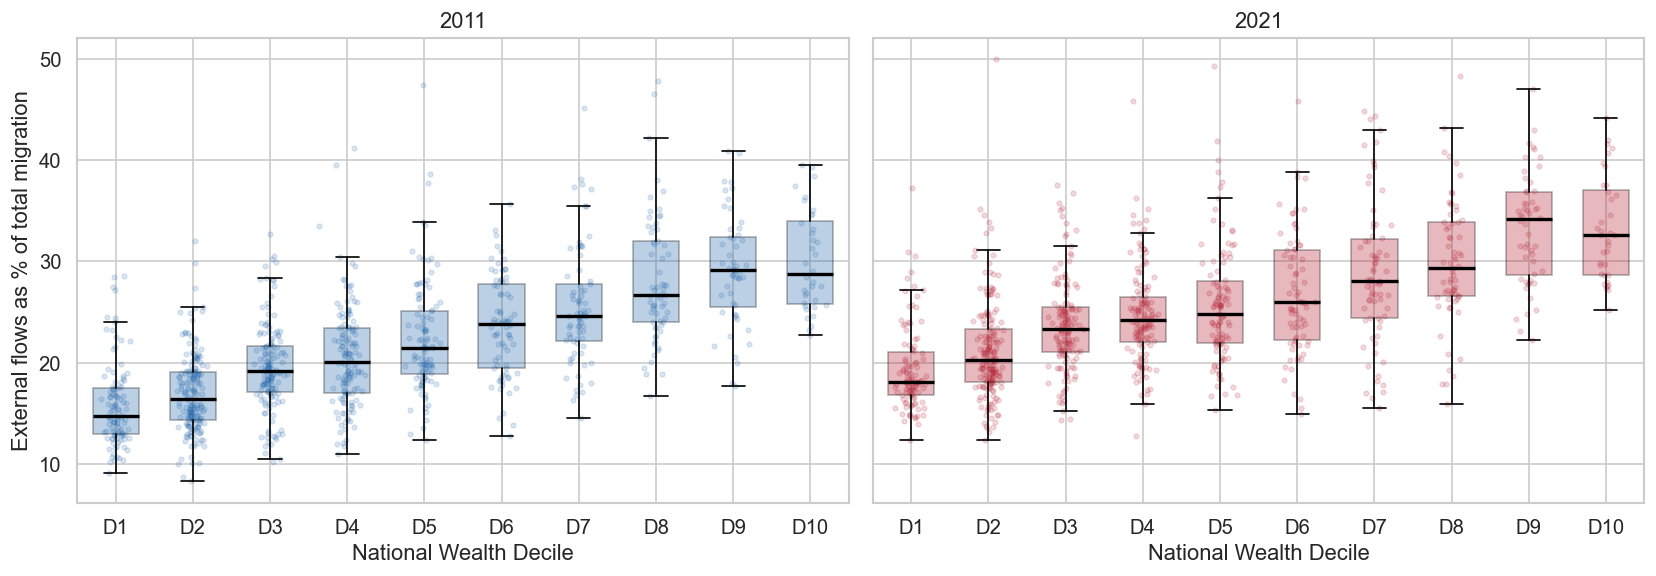

In [48]:
# ── Fig 19: External share by decile (box + strip) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
dec_col = 'Wealth_Decile_National'

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    col = f'Ext_Share_{yr}'
    
    data_by_dec = [df.loc[df[dec_col] == d, col].values for d in range(1, 11)]
    bp = ax.boxplot(data_by_dec, positions=range(1, 11), patch_artist=True,
                    widths=0.6, showfliers=False)
    for box in bp['boxes']:
        box.set_facecolor('#2166ac' if yr == '11' else '#b2182b')
        box.set_alpha(0.3)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(2)
    
    # Overlay strip
    for d in range(1, 11):
        vals = df.loc[df[dec_col] == d, col].values
        jitter = np.random.normal(0, 0.08, size=len(vals))
        ax.scatter(d + jitter, vals, alpha=0.15, s=8,
                   color='#2166ac' if yr == '11' else '#b2182b')
    
    ax.set_xlabel('National Wealth Decile')
    ax.set_title(f'20{yr}')
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f'D{d}' for d in range(1, 11)])

axes[0].set_ylabel('External flows as % of total migration')
# fig.suptitle('Fig 19: External Flow Share by National Decile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_19_external_share_by_decile.png', dpi=150)
plt.show()

### External flow intensity results & Fig 19 Interpretation

1st cell results in part-1d showed that **there is general increase in external flows from 2011 to 2021.**

In fig 19:
- The overall trend increased (shift upward in general) from 2011 to 2021, consistent with the increase external flows.
- Compared with more steady increase in 2011, there is a jump between D8 and D9, and decrease from D9 to D10 in 2021.

## 1e. The "National Boost", Decomposed: Reclassification vs External Flows

The earlier version of this section computed `national − London` (C − A) and labelled the whole quantity an *external-flow* contribution. 

That is incorrect, since C − A also contains the **reclassification** effect of switching decile ladders. 

With Frame B we separate them:

- **Reclassification (B − A)** 
    - moves that change cascade/counter status purely because the ladder changed, with *identical* flows.
- **External flows (C − B)** 
    - the extra volume injected by London↔outside moves, on the same ladder.


In [49]:
# ── Three-way decomposition: reclassification vs external flows ──────────
print('=' * 100)
print('THREE-WAY DECOMPOSITION: Reclassification vs External Flows')
print('=' * 100)
print("""
  A = London-internal flows, London-relative deciles   (original analysis)
  B = London-internal flows, NATIONAL deciles          (same flows, new ladder)
  C = London-internal + external flows, national deciles (full national frame)

  Reclassification effect = B - A   (switching the decile ladder)
  External flow effect    = C - B   (adding external flows)
  Total difference        = C - A   (what the old comparison showed)
""")

for yr in ['11', '21']:
    print(f'\n{"-" * 100}')
    print(f'  20{yr}')
    print(f'{"-" * 100}')
    print(f'{"Metric":>22s} {"Reclass (B-A)":>14s} {"External (C-B)":>15s} '
          f'{"Total (C-A)":>13s} {"% from reclass (Reclass / Total)":>15s}')
    print('-' * 100)
    for col, label in [
        ('CFI_Churn',          'Cascade churn'),
        ('Counter_Churn',      'Counter churn'),
        ('Net_Cascade',        'Net cascade'),
        ('Net_Counter',        'Net counter'),
        ('Cascade_Dominance',  'Cascade dominance'),
    ]:
        a = df[f'{col}_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_{yr}'].mean()
        b = df[f'{col}_intnat_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_intnat_{yr}'].mean()
        c = df[f'{col}_nat_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_nat_{yr}'].mean()
        reclass, external, total = b - a, c - b, c - a
        pct = (reclass / total * 100) if abs(total) > 0.001 else 0
        if 'Dominance' in col:
            print(f'  {label:>20s}  {reclass:>+13.4f}  {external:>+14.4f}  {total:>+12.4f}  {pct:>13.1f}%')
        else:
            print(f'  {label:>20s}  {reclass:>+13,.0f}  {external:>+14,.0f}  {total:>+12,.0f}  {pct:>13.1f}%')


THREE-WAY DECOMPOSITION: Reclassification vs External Flows

  A = London-internal flows, London-relative deciles   (original analysis)
  B = London-internal flows, NATIONAL deciles          (same flows, new ladder)
  C = London-internal + external flows, national deciles (full national frame)

  Reclassification effect = B - A   (switching the decile ladder)
  External flow effect    = C - B   (adding external flows)
  Total difference        = C - A   (what the old comparison showed)


----------------------------------------------------------------------------------------------------
  2011
----------------------------------------------------------------------------------------------------
                Metric  Reclass (B-A)  External (C-B)   Total (C-A) % from reclass (Reclass / Total)
----------------------------------------------------------------------------------------------------
         Cascade churn        -26,496        +191,243      +164,747          -16.1%
         Cou

### Interpretation

**Churn metrics (Cascade Churn & Counter Churn)**
- Both changes in churn metrics from ladder reclassification for London-only flows are relatively small (16% - 21%), and the majority should attribute to the addition of external flows.
- The changes for churn metrics are stable over the census periods.

**Net churn metrics (Net Cascade & Net Counter)**
- It is crucial relassification has zero numbers in these metrics, since we're using the same London-only flows.
- Though both increases in cascade and counter directions, the pattern of bigger increases in counter is striking.
- **Reclassification nudges toward cascade for both periods.**
- **Adding external flows nudges in opposite direction for 2011 and 2021.**
    - **It keeps nudging 2011 toward cascade, while push harder toward counter by 2021.**


The per-decile picture below shows where each component bites — note especially **D6**, where external flows are lateral by construction, so any height there is *pure reclassification*.


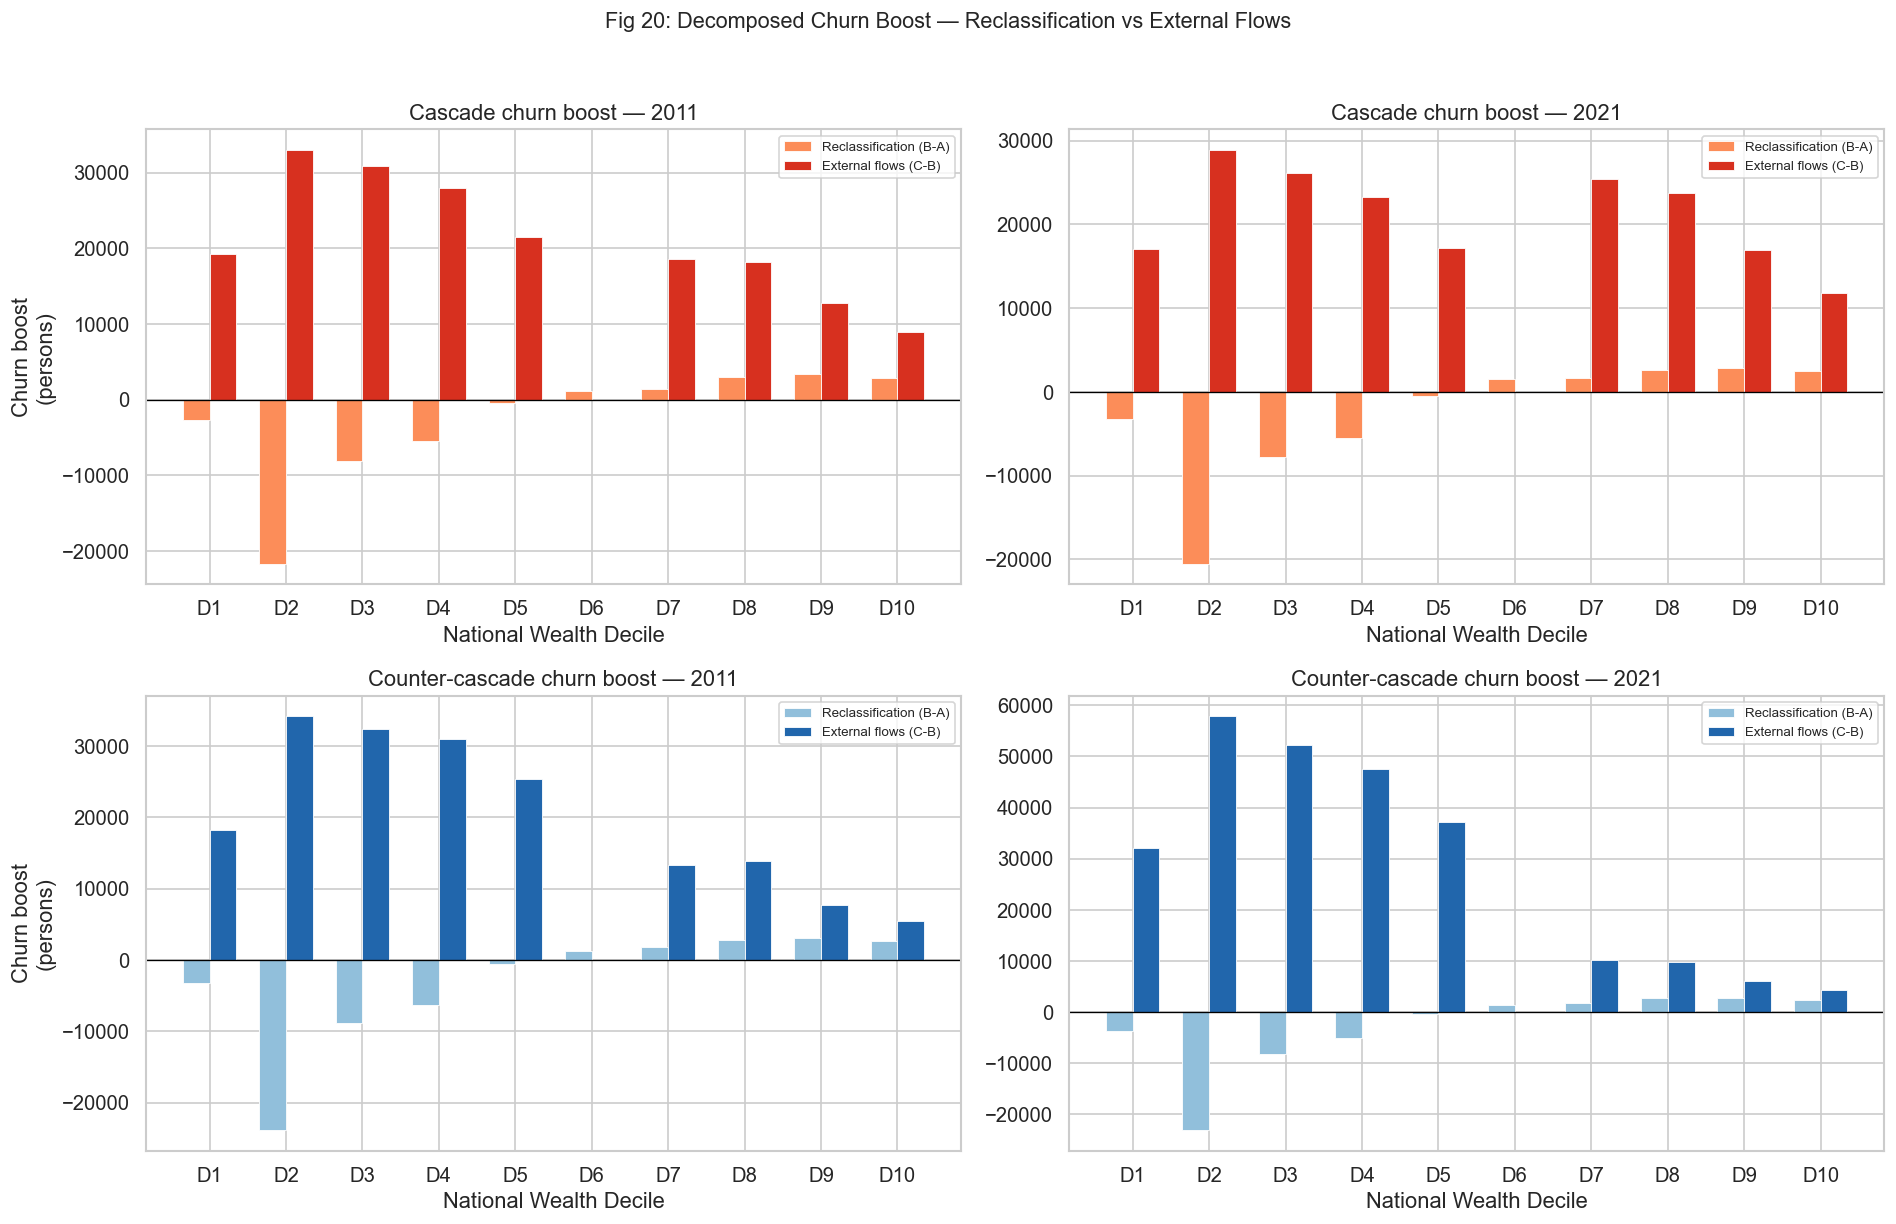

In [50]:
# ── Fig 20: stacked decomposition by decile ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(1, 11); w = 0.35

for row_idx, direction in enumerate(['cascade', 'counter']):
    for col_idx, yr in enumerate(['11', '21']):
        ax = axes[row_idx, col_idx]
        reclass_by_dec, external_by_dec = [], []
        for d in range(1, 11):
            mask = df['Wealth_Decile_National'] == d
            if direction == 'cascade':
                a = (df.loc[mask, f'Inflow_Wealthier_{yr}'].sum() + df.loc[mask, f'Outflow_Poorer_{yr}'].sum())
                b = (df.loc[mask, f'Inflow_Wealthier_intnat_{yr}'].sum() + df.loc[mask, f'Outflow_Poorer_intnat_{yr}'].sum())
                c = (df.loc[mask, f'Inflow_Wealthier_nat_{yr}'].sum() + df.loc[mask, f'Outflow_Poorer_nat_{yr}'].sum())
            else:
                a = (df.loc[mask, f'Outflow_Wealthier_{yr}'].sum() + df.loc[mask, f'Inflow_Poorer_{yr}'].sum())
                b = (df.loc[mask, f'Outflow_Wealthier_intnat_{yr}'].sum() + df.loc[mask, f'Inflow_Poorer_intnat_{yr}'].sum())
                c = (df.loc[mask, f'Outflow_Wealthier_nat_{yr}'].sum() + df.loc[mask, f'Inflow_Poorer_nat_{yr}'].sum())
            reclass_by_dec.append(b - a); external_by_dec.append(c - b)

        reclass_arr = np.array(reclass_by_dec); external_arr = np.array(external_by_dec)
        color_r = '#fc8d59' if direction == 'cascade' else '#91bfdb'
        color_e = '#d7301f' if direction == 'cascade' else '#2166ac'
        # ax.bar(x, reclass_arr, w * 2, label='Reclassification (B-A)', color=color_r, alpha=0.7, edgecolor='white', lw=0.5)
        # ax.bar(x, external_arr, w * 2, bottom=reclass_arr, label='External flows (C-B)', color=color_e, alpha=0.7, edgecolor='white', lw=0.5)
        # Instead of stacking with 'bottom=', place them side-by-side
        ax.bar(x - w/2, reclass_arr, w, label='Reclassification (B-A)', color=color_r, edgecolor='white', lw=0.5)
        ax.bar(x + w/2, external_arr, w, label='External flows (C-B)', color=color_e, edgecolor='white', lw=0.5)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel('National Wealth Decile'); ax.set_xticks(x); ax.set_xticklabels([f'D{d}' for d in x])
        title_dir = 'Cascade' if direction == 'cascade' else 'Counter-cascade'
        ax.set_title(f'{title_dir} churn boost — 20{yr}')
        if col_idx == 0: ax.set_ylabel('Churn boost\n(persons)')
        ax.legend(fontsize=8, loc='best')

fig.suptitle('Fig 20: Decomposed Churn Boost — Reclassification vs External Flows', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig_20_decomposed_churn_boost.png', dpi=150); plt.show()


### Fig 20 Interpretation

Each bar means each decile, splitting the cascade or counter churn boost by 2 reasons (ladder reclassification or addition of external flows).

- **D6 London MSOAs has ~zero external flow bars.**
    - This is by construction of external assigned as D6, where external moves to and from D6 London neighbourhoods are classified as later.
- **D1-D5 have large reclassification churn boosts, especially for counter.**
    - The ladder switch materially chanes what countes as cross-decile movement.
- **Compared with 2011, external counter boost bars dwarf in 2021, while relassification changes stay similar across years.** So there is temporal asymmetry between cascade and counter churn boost over census periods.


## 1f. Three-Way Flow Decomposition — Within London / Outside→London / London→Outside

The decomposition above separates *reclassification* from *external flows*. 

This section opens up the external flows themselves by **direction**, answering the question that most shapes the dissertation: 

**Is the counter-cascade shift driven by people **leaving** London, people *arriving* from outside, or *internal* churn?** 

**What drived the 2011 to 2021 *counter* shift?** 

For the ~69% of London MSOAs D1-D5 (below D6) the directional mapping is clean:
- **Outside → London** (`Ext_Inflow`) registers as `Inflow_Wealthier` → **cascade**
- **London → Outside** (`Ext_Outflow`) registers as `Outflow_Wealthier` → **counter**
- **Within London** feeds both, per the internal flows

For the minority above D6 the mapping flips. Because the cascade/counter *labels* of external flows depend on the D6 assignment, the directional *volumes* are robust, but their cascade/counter interpretation depends on D6.


In [51]:
# ── Decompose cross-decile churn by flow direction ──────────────────────
EXT = 6
labels = ['Within London', 'Outside->London', 'London->Outside']
store = {}
for yr in ['11', '21']:
    ei = df[f'Ext_Inflow_nat_{yr}'].fillna(0).values
    eo = df[f'Ext_Outflow_nat_{yr}'].fillna(0).values
    ndv = df['Wealth_Decile_National'].values

    out2ldn_casc = np.where(ndv < EXT, ei, 0).sum()   # Outside->London, D<6 -> Inflow_Wealthier (cascade)
    out2ldn_co   = np.where(ndv > EXT, ei, 0).sum()   # Outside->London, D>6 -> Inflow_Poorer  (counter)
    ldn2out_co   = np.where(ndv < EXT, eo, 0).sum()   # London->Outside, D<6 -> Outflow_Wealthier (counter)
    ldn2out_casc = np.where(ndv > EXT, eo, 0).sum()   # London->Outside, D>6 -> Outflow_Poorer  (cascade)

    iw_int = df[f'Inflow_Wealthier_nat_{yr}'].values  - np.where(ndv < EXT, ei, 0)
    op_int = df[f'Outflow_Poorer_nat_{yr}'].values    - np.where(ndv > EXT, eo, 0)
    ow_int = df[f'Outflow_Wealthier_nat_{yr}'].values - np.where(ndv < EXT, eo, 0)
    ip_int = df[f'Inflow_Poorer_nat_{yr}'].values     - np.where(ndv > EXT, ei, 0)
    within_casc = (iw_int + op_int).sum()
    within_co   = (ow_int + ip_int).sum()

    store[yr] = {'casc': [within_casc, out2ldn_casc, ldn2out_casc],
                 'co':   [within_co,   out2ldn_co,   ldn2out_co]}

print('=' * 84)
print('THREE-WAY FLOW DECOMPOSITION of cross-decile churn (city-wide, national frame)')
print('=' * 84)
for yr in ['11', '21']:
    cs, co = store[yr]['casc'], store[yr]['co']
    print(f'\n-- 20{yr} --')
    print(f"  {'Flow type':<20s}{'-> CASCADE':>15s}{'-> COUNTER':>15s}")
    for i, l in enumerate(labels):
        print(f'  {l:<20s}{cs[i]:>15,.0f}{co[i]:>15,.0f}')
    print(f"  {'-' * 48}")
    print(f"  {'TOTAL':<20s}{sum(cs):>15,.0f}{sum(co):>15,.0f}")
    chk_c, chk_co = df[f'CFI_Churn_nat_{yr}'].sum(), df[f'Counter_Churn_nat_{yr}'].sum()
    print(f'  reconcile: CFI_nat={chk_c:,.0f}  Counter_nat={chk_co:,.0f}  '
          f'(match: {abs(sum(cs)-chk_c) < 1 and abs(sum(co)-chk_co) < 1})')
    print(f'  aggregate dominance = {sum(cs)/(sum(cs)+sum(co)):.4f}')

delta = {}
for i, l in enumerate(labels):
    delta[l] = (store['21']['casc'][i] - store['11']['casc'][i],
                store['21']['co'][i]   - store['11']['co'][i])
print('\nWHAT DRIVES THE 2011->2021 COUNTER SHIFT?  (delta churn by flow type)')
print(f"  {'Flow type':<20s}{'delta cascade':>13s}{'delta counter':>13s}")
for l in labels:
    print(f'  {l:<20s}{delta[l][0]:>+13,.0f}{delta[l][1]:>+13,.0f}')

FLOW_DECOMP = {'store': store, 'delta': delta, 'labels': labels}


THREE-WAY FLOW DECOMPOSITION of cross-decile churn (city-wide, national frame)

-- 2011 --
  Flow type                -> CASCADE     -> COUNTER
  Within London               592,302        623,370
  Outside->London             132,756         40,267
  London->Outside              58,487        141,153
  ------------------------------------------------
  TOTAL                       783,545        804,790
  reconcile: CFI_nat=783,545  Counter_nat=804,790  (match: True)
  aggregate dominance = 0.4933

-- 2021 --
  Flow type                -> CASCADE     -> COUNTER
  Within London               576,646        645,696
  Outside->London             112,450         30,503
  London->Outside              77,805        226,890
  ------------------------------------------------
  TOTAL                       766,901        903,089
  reconcile: CFI_nat=766,901  Counter_nat=903,089  (match: True)
  aggregate dominance = 0.4592

WHAT DRIVES THE 2011->2021 COUNTER SHIFT?  (delta churn by flow type)
  

### Interpretation:

To answer the question of ***"What drives the 2011 to 2021 counter shift"***, we focus on the bottom `d counter` column:
- **London to external migration accounts for the vast majority of the new counter-churn volume**, increased by +85,737.
- **Within London as internal reshuffling, contributed to the counter shift, but it is distinctly a secondary factor**, increased by +22,326.
- **External to London migration made by fewer people in counter direction in 2021 than in 2011**, decreased by -9,764.
    - It worth notice that **both the cascade and counter component of external to London flow decreased, meaning the total overall inflow to London from the rest of the country shrank**.
    - Though the decrease of counter volume means **inflows from external actively resisted the overall upward trend**.


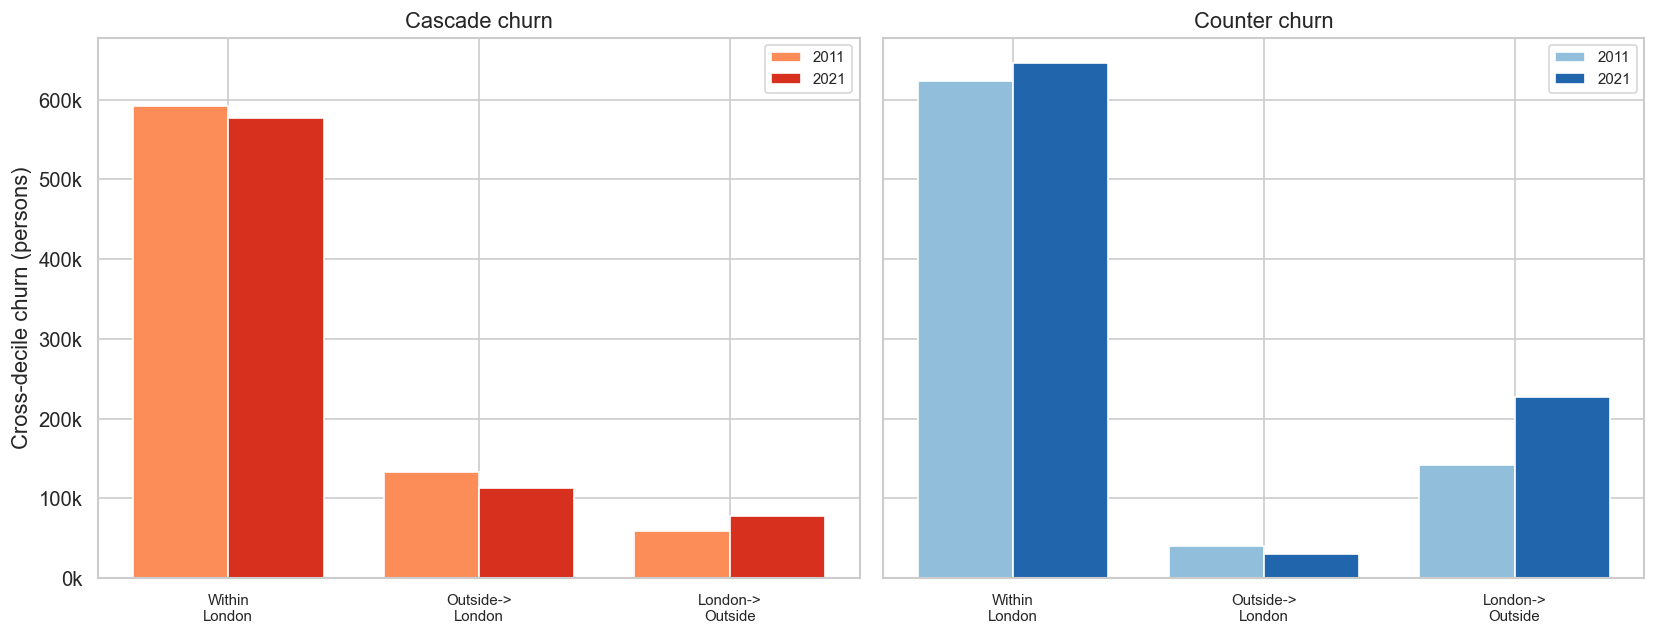

In [52]:
# ── Fig 20b: cross-decile churn by flow direction, 2011 vs 2021 ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
xpos = np.arange(3); w = 0.38
short = ['Within\nLondon', 'Outside->\nLondon', 'London->\nOutside']

# Updated the hex codes here to match Fig 20 exactly
for ax, (metric, title, c11, c21) in zip(
        axes, [('casc', 'Cascade churn', '#fc8d59', '#d7301f'),
               ('co',   'Counter churn', '#91bfdb', '#2166ac')]):
    v11 = FLOW_DECOMP['store']['11'][metric]
    v21 = FLOW_DECOMP['store']['21'][metric]
    
    ax.bar(xpos - w/2, v11, w, label='2011', color=c11, edgecolor='white')
    ax.bar(xpos + w/2, v21, w, label='2021', color=c21, edgecolor='white')
    ax.set_xticks(xpos); ax.set_xticklabels(short, fontsize=9)
    ax.set_title(title); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

axes[0].set_ylabel('Cross-decile churn (persons)')
# fig.suptitle('Fig 20b: Cross-Decile Churn by Flow Direction — 2011 vs 2021', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig_20b_flow_direction_decomposition.png', dpi=150); plt.show()

### Fig 20b Interpretation

This is the visualisation of above number analysis.

- The **biggest jump is the "London->Outside" in counter churn**, where the dark blue bar in 2021 absolutely dwarfs the light blue bar in 2011. Visually the volume nearly doubled in 2021.

- **Internal city churn makes up the largest baseline volume of people. .**
    - The "Within London" columns are physically the tallest on the chart.
    - But the change between bars for "Within London" is relatively modest, compared to the dramatic stair-step jump seen in the "London->Outside" bars.

**This fig also helps to justify basing core analysis on the "Within London" churn, while framing the "External flows" as supplementary context.**
- **Core analysis: How London is reshaping itself?**
- **Complementray: London is not a vacuum. While internal churn remained high, the actual shift in the counter-trend was heavily impacted by an exodus of people leaving the city entirely.**


Caveat: the 2021 Census was taken in March 2021 under lockdown, which both *caused* the suburbanisation and *degraded* migration measurement (more suppression/imputation). The within-London decline should not be over-read as real behavioural change.


---
# PART 2: What Shifts in the Cascade-Counter Balance?

---

## 2a. Headline Comparison: London-only vs National Frame

In [53]:
# ── Headline: A -> B -> C decomposition (per-MSOA means) ─────────────────
print('=' * 96)
print('HEADLINE METRIC COMPARISON: A -> B -> C  (per-MSOA means)')
print('=' * 96)
metrics = [('CFI_Churn', 'Cascade churn'), ('Counter_Churn', 'Counter churn'),
           ('Net_Cascade', 'Net cascade'), ('Net_Counter', 'Net counter'),
           ('Cascade_Dominance', 'Cascade dominance'), ('Cross_Decile_Share', 'Cross-decile share')]
for yr in ['11', '21']:
    m = df[f'Total_Migration_nat_{yr}'] != 0
    print(f'\n-- 20{yr}  (N={int(m.sum())}) ' + '-' * 72)
    print(f"{'Metric':>20s}{'A (Ldn)':>13s}{'B (NatDec)':>13s}{'C (Nat+Ext)':>13s}"
          f"{'Reclass B-A':>13s}{'Ext C-B':>13s}")
    print('-' * 96)
    for col, label in metrics:
        a = df.loc[m, f'{col}_{yr}'].mean(); b = df.loc[m, f'{col}_intnat_{yr}'].mean(); c = df.loc[m, f'{col}_nat_{yr}'].mean()
        wide = ('Dominance' in col or 'Share' in col)
        fmt = '.4f' if wide else '.1f'
        print(f'  {label:>18s}{a:>13{fmt}}{b:>13{fmt}}{c:>13{fmt}}{b-a:>+13{fmt}}{c-b:>+13{fmt}}')


HEADLINE METRIC COMPARISON: A -> B -> C  (per-MSOA means)

-- 2011  (N=982) ------------------------------------------------------------------------
              Metric      A (Ldn)   B (NatDec)  C (Nat+Ext)  Reclass B-A      Ext C-B
------------------------------------------------------------------------------------------------
       Cascade churn        630.1        603.2        797.9        -27.0       +194.7
       Counter churn        666.7        634.8        819.5        -32.0       +184.7
         Net cascade          0.0          0.0         75.6         +0.0        +75.6
         Net counter          0.0          0.0        102.7         +0.0       +102.7
   Cascade dominance       0.4796       0.4814       0.4862      +0.0018      +0.0049
  Cross-decile share       0.8288       0.8023       0.8227      -0.0265      +0.0204

-- 2021  (N=982) ------------------------------------------------------------------------
              Metric      A (Ldn)   B (NatDec)  C (Nat+Ext)  

> Frame A uses the *London-relative* ladder; Frame C uses the *national* ladder. That difference is the reclassification effect (B − A), now shown separately from the external-flow effect (C − B). 
>
> The "London vs national" gap was never a clean external-flow measure; the `Reclass` and `Ext` columns above split it correctly.


In [54]:
# ── Aggregate city-wide sums (persons) ──────────────────────────────────
print('=' * 96)
print('AGGREGATE SUMS (city-wide totals, persons)')
print('=' * 96)
for yr in ['11', '21']:
    print(f'\n-- 20{yr} --')
    for m in ['CFI_Churn', 'Counter_Churn', 'Net_Cascade', 'Net_Counter']:
        a = df[f'{m}_{yr}'].sum(); b = df[f'{m}_intnat_{yr}'].sum(); c = df[f'{m}_nat_{yr}'].sum()
        print(f'  {m:>16s}:  A={a:>12,.0f}  B={b:>12,.0f}  C={c:>12,.0f}  '
              f'reclass={b-a:>+10,.0f}  external={c-b:>+10,.0f}')


AGGREGATE SUMS (city-wide totals, persons)

-- 2011 --
         CFI_Churn:  A=     618,798  B=     592,302  C=     783,545  reclass=   -26,496  external=  +191,243
     Counter_Churn:  A=     654,748  B=     623,370  C=     804,790  reclass=   -31,378  external=  +181,420
       Net_Cascade:  A=           0  B=           0  C=      74,269  reclass=        +0  external=   +74,269
       Net_Counter:  A=           0  B=           0  C=     100,886  reclass=        +0  external=  +100,886

-- 2021 --
         CFI_Churn:  A=     603,136  B=     576,646  C=     766,901  reclass=   -26,490  external=  +190,255
     Counter_Churn:  A=     674,624  B=     645,696  C=     903,089  reclass=   -28,928  external=  +257,393
       Net_Cascade:  A=           0  B=           0  C=      34,645  reclass=        +0  external=   +34,645
       Net_Counter:  A=           0  B=           0  C=     196,387  reclass=        +0  external=  +196,387


### Interpretation (Refer and recall from 1e above)

**Reclassification effect:**
- ***Churn and Cross-decile share drop.***
    - On a within-London reference, London was forced into 10 equal buckets with London-only analysis. This artificially slice massive relatively deprived neighbourhoods. But switching to national reference dissolved the grained artificial slices, and lumped those MSOAs back into large, broad national buckets.
    - So, many London neighbourhoods that are in different deciles locally actually fall into the same decile nationally, local moves aren't crossing social boundaries under the national lens. This causes the overall churn and cross-decile share to drop.

**Adding External Flows (London is an open system):**
- ***External flows drive real net changes (consistent with 1f and fig 20).***
    - From frame B to frame C, both Net_Cascade and Net_Counter jump above zero.
    - The external flows add massive volumes.

**Surge of Counter shift from 2011 to 2021:**
- ***External effect on Counter Churn is massive in 2021, compared with 2011*** (+257,393 people in 2021, +181,420 people in 2011)
- ***Net Counter dominates in 2021, while external flows brought a relatively balanced net change***.
- ***`Cascade_Dominance` nudges toward cascade in 2011, but pushes hard toward counter by 2021, with a drop from 0.4862 to 0.4551. But both periods have the counter dominance, across all 3 frames.***
    - By 2021, London's interaction with the outside neighbourhoods became highly skewed toward "counter" (upward) mobility, implying gentrification, displacement, or wealth-consolidation dynamics at the borders.
    - **People moving into or out of the city were vastly more likely to be involved in moves toward wealthier deciles than in 2011**, radically changing the socio-economic makeup of the city in a way internal reshuffling masks.
        - In 2011, there are 181,420 external counter churn;
        - In 2021, there are 257,393 external counter churn (+75,973 massive increase).
        - cascade churn remained entirely flat (191,243 in 2011 - 190,255 in 2021).



## 2b. Cascade Dominance Shift, Decomposed

The per-MSOA dominance shift `national − London` (C − A) is the headline of the boundary analysis. 

We split it into its **reclassification** (B − A) and **external** (C − B) components, so the shift is no longer a single conflated number.


In [55]:
# ── Decompose the per-MSOA dominance shift ──────────────────────────────
for yr in ['11', '21']:
    df[f'Dom_Reclass_{yr}']  = df[f'Cascade_Dominance_intnat_{yr}'] - df[f'Cascade_Dominance_{yr}']
    df[f'Dom_External_{yr}'] = df[f'Cascade_Dominance_nat_{yr}']    - df[f'Cascade_Dominance_intnat_{yr}']
    df[f'Dom_Shift_{yr}']    = df[f'Cascade_Dominance_nat_{yr}']    - df[f'Cascade_Dominance_{yr}']

print('=== Cascade Dominance Shift, decomposed (per-MSOA) ===')
for yr in ['11', '21']:
    m = df[f'Total_Migration_nat_{yr}'] != 0
    r, e, t = df.loc[m, f'Dom_Reclass_{yr}'], df.loc[m, f'Dom_External_{yr}'], df.loc[m, f'Dom_Shift_{yr}']
    print(f'\n  20{yr}  (N={int(m.sum())}):')
    print(f'    Reclassification (B-A): mean {r.mean():+.5f}   median {r.median():+.5f}')
    print(f'    External flows   (C-B): mean {e.mean():+.5f}   median {e.median():+.5f}')
    print(f'    Total shift      (C-A): mean {t.mean():+.5f}   median {t.median():+.5f}')
    tot = t.mean()
    if abs(tot) > 1e-9:
        print(f'    Share of mean shift:  reclass {r.mean()/tot*100:4.0f}%   external {e.mean()/tot*100:4.0f}%')
    tc = (t > 0.001).sum(); cc = (t < -0.001).sum()
    print(f'    MSOAs shifting toward cascade {tc} / counter {cc} / negligible {int(m.sum())-tc-cc}')


=== Cascade Dominance Shift, decomposed (per-MSOA) ===

  2011  (N=982):
    Reclassification (B-A): mean +0.00181   median +0.00133
    External flows   (C-B): mean +0.00486   median +0.00000
    Total shift      (C-A): mean +0.00667   median +0.00148
    Share of mean shift:  reclass   27%   external   73%
    MSOAs shifting toward cascade 500 / counter 454 / negligible 28

  2021  (N=982):
    Reclassification (B-A): mean +0.00104   median +0.00080
    External flows   (C-B): mean -0.01034   median -0.02944
    Total shift      (C-A): mean -0.00930   median -0.02891
    Share of mean shift:  reclass  -11%   external  111%
    MSOAs shifting toward cascade 309 / counter 655 / negligible 18


### Interpretation (consistent with 1e above)

**Confirming external flows is the primary engine of cascade/counter shift**, while simply grading London on a national wealth laffer is a minor maths artifact.

- In 2021, external flows account for 111% of the mean shift, completely overpowering the slight offset from reclassification (-11%). Still, they account for 73% back in 2011. 

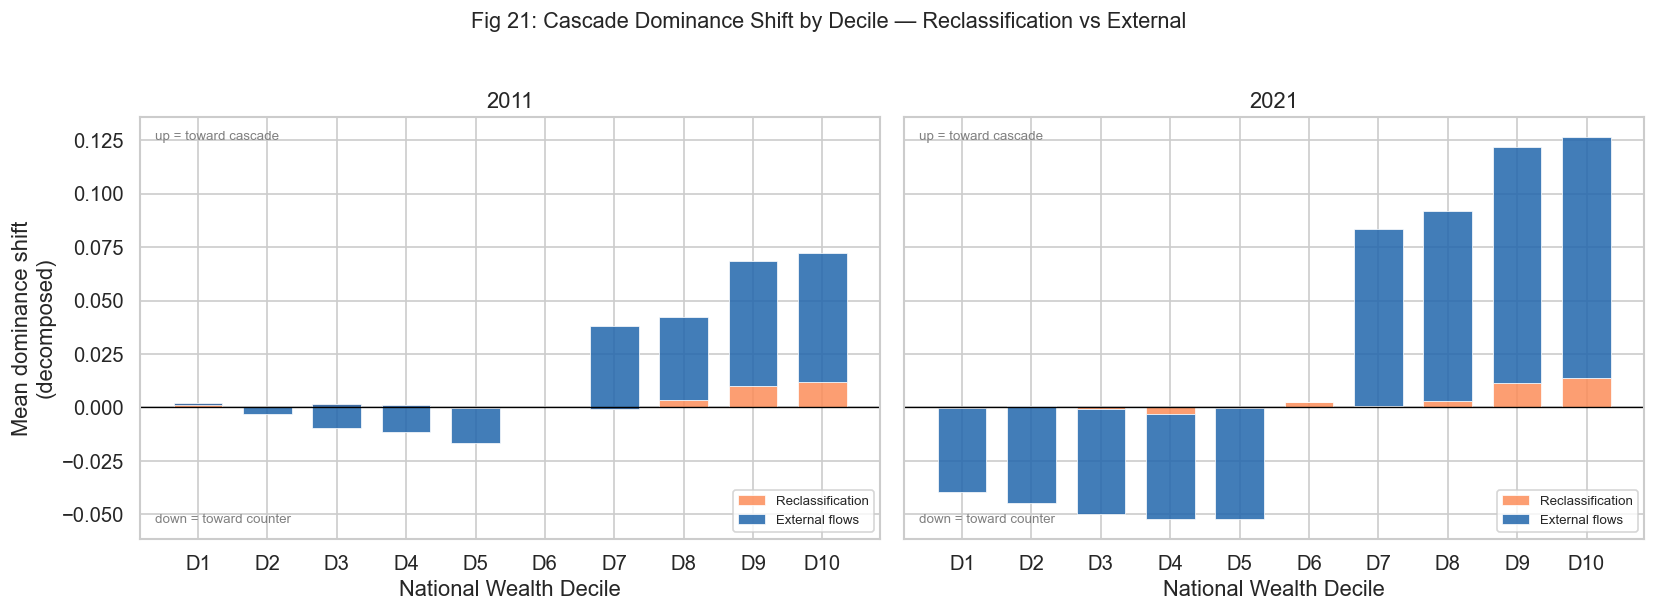

In [56]:
# ── Fig 21: dominance shift by decile, decomposed (stacked) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
dec = 'Wealth_Decile_National'; x = np.arange(1, 11)
for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    r = np.nan_to_num(df.groupby(dec)[f'Dom_Reclass_{yr}'].mean().reindex(range(1, 11)).values)
    e = np.nan_to_num(df.groupby(dec)[f'Dom_External_{yr}'].mean().reindex(range(1, 11)).values)
    ax.bar(x, r, 0.7, label='Reclassification', color='#fc8d59', alpha=0.85, edgecolor='white', lw=0.5)
    ax.bar(x, e, 0.7, bottom=r, label='External flows', color='#2166ac', alpha=0.85, edgecolor='white', lw=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('National Wealth Decile'); ax.set_title(f'20{yr}')
    ax.set_xticks(x); ax.set_xticklabels([f'D{d}' for d in x])
    ax.text(0.02, 0.97, 'up = toward cascade', transform=ax.transAxes, fontsize=8, color='grey', va='top')
    ax.text(0.02, 0.03, 'down = toward counter', transform=ax.transAxes, fontsize=8, color='grey', va='bottom')
    ax.legend(fontsize=8, loc='lower right')
axes[0].set_ylabel('Mean dominance shift\n(decomposed)')
fig.suptitle('Fig 21: Cascade Dominance Shift by Decile — Reclassification vs External', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig_21_dominance_shift_decomposed.png', dpi=150); plt.show()


### Fig 21 Interpretation

Even in 2021, there are larger cascade shifts, there are much less number of MSOAs above D6 (~69% MSOAs are below D6). So the whole shift is in the counter direction.  

- ***External migration acts opposite between London's wealthier and poorer neighbourhoods, with a clear structural split***.
    - External migration reinforces the existing counter-dominant trends in the lower deciles, while simultaneously pulling the upper deciles in the opposite cascade direction.
    - External flows push wealthier MSOAs (D7-D10) heavily toward **cascade dominance**.
    - External flows push lower deciles significantly toward **counter dominance**.

- ***The composite effects of aggregating pulls toward Counter*** (core finding in the study)
    - ~69.1% London MSOAs are below national D6 (results in data preprocess 20260625)
    - Because the vast majority of London's neighbourhoods are concentrated in the lower deciles, the counter push exerted by external flows on these specific areas completely overwhelms the extreme.
    - Cascade push occurring in the wealthy minority.

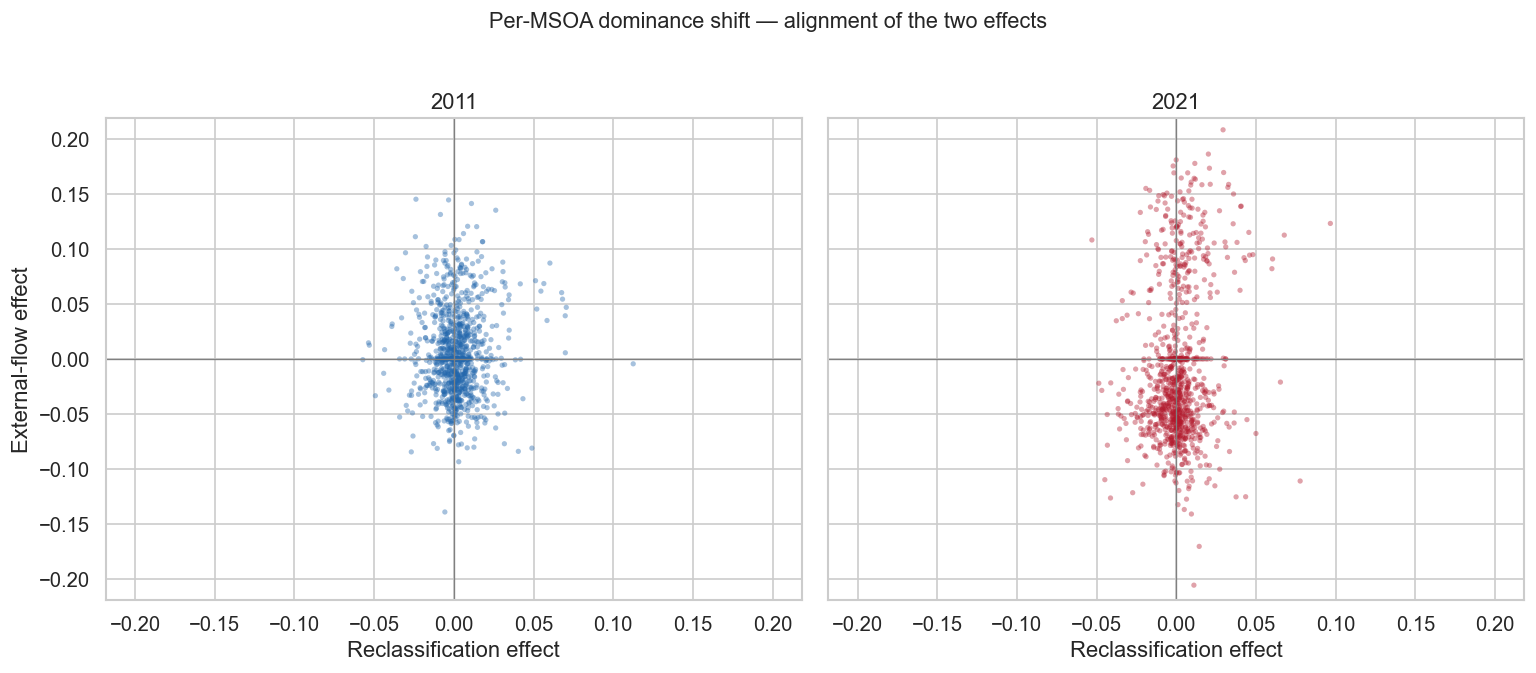

In [57]:
# ── Fig 22: per-MSOA scatter — do the two effects align or oppose? ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    ax.scatter(df[f'Dom_Reclass_{yr}'], df[f'Dom_External_{yr}'], s=10, alpha=0.4,
               color='#2166ac' if yr == '11' else '#b2182b', edgecolors='none')
    ax.axhline(0, color='grey', lw=0.8); ax.axvline(0, color='grey', lw=0.8)
    lim = max(df[f'Dom_Reclass_{yr}'].abs().max(), df[f'Dom_External_{yr}'].abs().max()) * 1.05
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Reclassification effect'); ax.set_title(f'20{yr}')
    # ax.text(0.97, 0.97, 'both -> cascade', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='grey')
    # ax.text(0.03, 0.03, 'both -> counter', transform=ax.transAxes, ha='left', va='bottom', fontsize=8, color='grey')
axes[0].set_ylabel('External-flow effect')
fig.suptitle('Per-MSOA dominance shift — alignment of the two effects', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig_22_dominance_shift_scatter.png', dpi=150); plt.show()


### Fig 22 Interpretation

***External flows are the undeniable driving force behind the shifts.***
- In both 2011 and 2021 panels, dots are tightly compressed horizontally around zero x, meaning reclassidication effect has a negligible impact on almost every single MSOA
- Massive vertical spread along the y-axis confirms again external flows as the diriving force behind the shifts.

***Magnitude and intensity of external migration's impact on London neighbourhoods grew significantly over the decade.***
- Comparing 2 panels side-by-side, 2011 plot shows a relatively compact vertical spread.
- By 2021, the vertical spread ahs stretches dramatically in both direction, confirming both growth in magnitude and intensity.

***Visualisation of 69% more deprived London MSOAs.***
- A dense, heavy cluster of dots in the bottom half of the graph, meaning the majority of MSOAs being pushed toward counter.
- A much more stretched-out, less dense scattering of dots stretching high in to the top half, meaning the minority of wealthy MSOAs with extreme cascade shift.

## 2c. Cross_Decile_Share Comparison

In [58]:
# ── Cross_Decile_Share: A -> B -> C ─────────────────────────────────────
print('=== Cross_Decile_Share: A -> B -> C ===')
for yr in ['11', '21']:
    m = df[f'Total_Migration_nat_{yr}'] != 0
    a = df.loc[m, f'Cross_Decile_Share_{yr}']; b = df.loc[m, f'Cross_Decile_Share_intnat_{yr}']; c = df.loc[m, f'Cross_Decile_Share_nat_{yr}']
    print(f'\n  20{yr}  (N={int(m.sum())}):')
    print(f'    A (Ldn)     mean {a.mean():.4f}  median {a.median():.4f}')
    print(f'    B (NatDec)  mean {b.mean():.4f}  median {b.median():.4f}   reclass {b.mean()-a.mean():+.4f}')
    print(f'    C (Nat+Ext) mean {c.mean():.4f}  median {c.median():.4f}   external {c.mean()-b.mean():+.4f}')


=== Cross_Decile_Share: A -> B -> C ===

  2011  (N=982):
    A (Ldn)     mean 0.8288  median 0.8498
    B (NatDec)  mean 0.8023  median 0.8219   reclass -0.0265
    C (Nat+Ext) mean 0.8227  median 0.8434   external +0.0204

  2021  (N=982):
    A (Ldn)     mean 0.8351  median 0.8555
    B (NatDec)  mean 0.8119  median 0.8259   reclass -0.0232
    C (Nat+Ext) mean 0.8350  median 0.8540   external +0.0231


### Interpretation

- Reclassification dropping effects are consistent with 2a above.

- Adding external flows liftting cross-decile share.
    - 69.1% MSOAs interacting with external neighbourhoods are below D6, this definitely increases the cross-decile moves.

## 2d. Sign Concordance Comparison

In [59]:
# ── Sign Concordance: A -> B -> C ───────────────────────────────────────
print('=== Sign Concordance: A -> B -> C ===')
for yr in ['11', '21']:
    m = df[f'Total_Migration_nat_{yr}'] != 0
    print(f'\n-- 20{yr}  (N={int(m.sum())}) --')
    for frame, suf in [('A (Ldn)', ''), ('B (NatDec)', '_intnat'), ('C (Nat+Ext)', '_nat')]:
        counts = df.loc[m, f'Sign_Concordance{suf}_{yr}'].value_counts()
        line = '   '.join(f'{v}: {int(counts.get(v, 0)):>4d}' for v in ['concordant', 'divergent', 'zero'])
        print(f'    {frame:>12s}   {line}')


=== Sign Concordance: A -> B -> C ===

-- 2011  (N=982) --
         A (Ldn)   concordant:  894   divergent:   87   zero:    1
      B (NatDec)   concordant:  896   divergent:   84   zero:    2
     C (Nat+Ext)   concordant:  903   divergent:   78   zero:    1

-- 2021  (N=982) --
         A (Ldn)   concordant:  878   divergent:  101   zero:    3
      B (NatDec)   concordant:  877   divergent:  104   zero:    1
     C (Nat+Ext)   concordant:  855   divergent:  126   zero:    1


In [60]:
# ── Detailed Sign Concordance Quadrants: A -> B -> C (Tabular) ──────────
print('=== Sign Concordance Quadrants: A -> B -> C ===')

# Set the columns for our table
quadrant_order = [
    'Upward-connected hub', 
    'Downward-connected hub', 
    'Net receiver', 
    'Net exporter', 
    'Zero'
]

for yr in ['11', '21']:
    # Filter mask for non-zero migration
    m = df[f'Total_Migration_nat_{yr}'] != 0
    print(f'\n-- 20{yr}  (N={int(m.sum())}) --\n')
    
    # List to hold the row data for this year's table
    table_data = []
    
    for frame, suf in [('A (Ldn)', ''), ('B (NatDec)', '_intnat'), ('C (Nat+Ext)', '_nat')]:
        # Extract net cascade and counter columns
        nc  = df[f'Net_Cascade{suf}_{yr}']
        nco = df[f'Net_Counter{suf}_{yr}']
        
        # Build the quadrant series
        q = pd.Series('Zero', index=df.index)
        q[(nc > 0) & (nco > 0)] = 'Upward-connected hub'
        q[(nc < 0) & (nco < 0)] = 'Downward-connected hub'
        q[(nc > 0) & (nco < 0)] = 'Net receiver'
        q[(nc < 0) & (nco > 0)] = 'Net exporter'
        
        # Calculate value counts
        counts = q[m].value_counts()
        
        # Build the row dictionary
        row = {'Frame': frame}
        for quad in quadrant_order:
            row[quad] = int(counts.get(quad, 0))
            
        table_data.append(row)
        
    # Convert to DataFrame, set the index to 'Frame', and print as a formatted table
    df_table = pd.DataFrame(table_data).set_index('Frame')
    
    print(df_table.to_string())
    print('\n' + '-'*100) # Adds a separator line between years

=== Sign Concordance Quadrants: A -> B -> C ===

-- 2011  (N=982) --

             Upward-connected hub  Downward-connected hub  Net receiver  Net exporter  Zero
Frame                                                                                      
A (Ldn)                       390                     504            45            42     1
B (NatDec)                    399                     497            43            41     2
C (Nat+Ext)                   525                     378            25            53     1

----------------------------------------------------------------------------------------------------

-- 2021  (N=982) --

             Upward-connected hub  Downward-connected hub  Net receiver  Net exporter  Zero
Frame                                                                                      
A (Ldn)                       377                     501            52            49     3
B (NatDec)                    387                     490            4

### Interpretation

Both **decreases in "Upward-connected hub" and "Downward-connected hub"** over the periods, even considering external flows, but the changes are **relatively stable**.

Without considering external flows, London has both increases of "Net receivers" and "Net exporters".

With external flows, 
- as we discussed above about the divergent forces of cascade/counter dominance, splitting on wealthier MSOAs and poorer MSOAs, 
- they also have **divergent forces on number of "Net receivers" and "Net exporters"**
    - Net receivers drop to 10 from 25 (60% decrease)
    - Net exporters strikingly rise to 116 from 53 (118.9% increase)

***In both 2011 and 2021, "Upward-connected hubs" are the majority among all categories. (517 in 2021 - 52.6%; 525 in 2011 - 53.5%)***
- In 2a above, people moving into or out of the city were vastly more likely to be involved in moves toward wealthier deciles than in 2011.
- **Why migration volume go up while upward-connected hubs decrease?**
    1. Even more people moving upward, they're filtering through slightly fewer hubs.
    2. Because of doubled net exporters in 2021, some balanced upward-connected hubs in 2011 likely experienced extreme outward migration by 2021, and became net exporters.

**Despite the count increasing over the periods, both Net receivers and Net exporters are still small proportions on the national frame.**
- Net receivers 25 in 2011 - 2.5%; 53 in 2021 - 5.4%.
- Net exporters 10 in 2011 - 1.0%; 116 in 2021 - 11.8%.

---
# PART 3: Does the Typology Change?

### Methodological note (updated)

The national-frame metrics differ from London-only metrics in two ways — a **different decile ladder** and **added external flows**. The earlier draft stated these "cannot be cleanly separated in the current data." **With Frame B, they can.** We assign the typology under all three frames and attribute every switch:

- **A → B** — switches caused purely by the **decile-ladder change** (reclassification).
- **B → C** — switches caused purely by **external flows**.
- **A → C** — the total, which the cross-tabs report.

This replaces the indirect "same-decile" proxy used previously, which mis-attributed switches: a move is reclassified whenever *either* endpoint changes decile, not only when the focal MSOA does — so focal-MSOA decile stability is **not** a valid proxy for "no reclassification" (demonstrated numerically in 3c-i).

## 3a. Typology Assignment — All Three Frames

EDA 3 thresholds (`Cascade_Dominance` > 0.52 → Cascade-led; < 0.48 → Counter-led; else Symmetric; `Cross_Decile_Share` < P25 → Lateral), applied within each frame using that frame's own P25 **computed over valid (non-suppressed) MSOAs**. The 20 suppressed 2021 MSOAs carry a distinct `'Suppressed'` label rather than being miscounted as `'Lateral'`, and are excluded from the P25 so they cannot distort the classification threshold.


In [61]:
# ── Typology under all three frames ─────────────────────────────────────

def assign_typology(dom, cds, cds_threshold, dom_upper=0.52, dom_lower=0.48):
    """Classify an MSOA into a flow-regime typology."""
    if cds < cds_threshold:
        return 'Lateral'
    if dom > dom_upper:
        return 'Cascade-led'
    if dom < dom_lower:
        return 'Counter-led'
    return 'Symmetric'

# ── London-only typology (same as EDA 3) ──────────────────────
for yr in ['11', '21']:
    cds_p25 = df[f'Cross_Decile_Share_{yr}'].quantile(0.25)
    df[f'Typology_{yr}'] = [
        assign_typology(dom, cds, cds_threshold=cds_p25)
        for dom, cds in zip(df[f'Cascade_Dominance_{yr}'], 
                            df[f'Cross_Decile_Share_{yr}'])
    ]

# ── National-frame typology ───────────────────────────────────
for yr in ['11', '21']:
    cds_p25_nat = df[f'Cross_Decile_Share_nat_{yr}'].quantile(0.25)
    df[f'Typology_nat_{yr}'] = [
        assign_typology(dom, cds, cds_threshold=cds_p25_nat)
        for dom, cds in zip(df[f'Cascade_Dominance_nat_{yr}'], 
                            df[f'Cross_Decile_Share_nat_{yr}'])
    ]
    print(f'Cross_Decile_Share P25 (20{yr}): London={df[f"Cross_Decile_Share_{yr}"].quantile(0.25):.4f}, '
          f'National={cds_p25_nat:.4f}')

print('\n=== Typology Counts ===')
order = ['Cascade-led', 'Symmetric', 'Counter-led', 'Lateral']
for yr in ['11', '21']:
    print(f'\n── 20{yr} ──')
    print(f'{"Type":>14s} {"London":>8s} {"National":>10s} {"Change":>8s}')
    for t in order:
        n_ldn = (df[f'Typology_{yr}'] == t).sum()
        n_nat = (df[f'Typology_nat_{yr}'] == t).sum()
        print(f'  {t:>12s}  {n_ldn:>6d}  {n_nat:>8d}  {n_nat - n_ldn:>+6d}')


Cross_Decile_Share P25 (2011): London=0.7825, National=0.7522
Cross_Decile_Share P25 (2021): London=0.7924, National=0.7754

=== Typology Counts ===

── 2011 ──
          Type   London   National   Change
   Cascade-led     129       213     +84
     Symmetric     268       243     -25
   Counter-led     339       280     -59
       Lateral     246       246      +0

── 2021 ──
          Type   London   National   Change
   Cascade-led      76       195    +119
     Symmetric     244        89    -155
   Counter-led     416       452     +36
       Lateral     246       246      +0


In [62]:
# ── Inner London (statutory) for the ring split ─────────────────────────
INNER_LONDON = {
    'Camden','City of London','Greenwich','Hackney','Hammersmith and Fulham',
    'Haringey','Islington','Kensington and Chelsea','Lambeth','Lewisham',
    'Newham','Southwark','Tower Hamlets','Wandsworth','Westminster',
}
df['Ring'] = np.where(df['ladnm'].isin(INNER_LONDON), 'Inner', 'Outer')

In [65]:
# ── Temporal typology transition, Frame C: 2011 → 2021 ───────────────────
order = ['Cascade-led', 'Symmetric', 'Lateral', 'Counter-led']
ct = (pd.crosstab(df['Typology_nat_11'], df['Typology_nat_21'])
        .reindex(index=order, columns=order).fillna(0).astype(int))
print('COUNTS (rows=2011, cols=2021):\n', ct.to_string())
print('\nROW % (where each 2011 class went):\n',
      (ct.div(ct.sum(axis=1), axis=0) * 100).round(1).to_string())

for ring in ['Inner', 'Outer']:
    s = df[df['Ring'] == ring]
    c = (pd.crosstab(s['Typology_nat_11'], s['Typology_nat_21'])
           .reindex(index=order, columns=order).fillna(0).astype(int))
    print(f'\n--- {ring} (n={len(s)}) ---\n', c.to_string())

print('=== Typology counts: A / B / C ===')
for yr in ['11', '21']:
    # Calculate valid N on the fly (~supp translates to != 0)
    valid_N = int((df[f'Total_Migration_nat_{yr}'] != 0).sum())
    
    print(f'\n-- 20{yr}  (valid N={valid_N}) --')
    print(f"{'Type':>14s}{'A (Ldn)':>11s}{'B (NatDec)':>12s}{'C (Nat+Ext)':>13s}")
    for t in order:
        a = (df[f'Typology_{yr}'] == t).sum()
        b = (df[f'Typology_intnat_{yr}'] == t).sum()
        c = (df[f'Typology_nat_{yr}'] == t).sum()
        print(f'  {t:>12s}{a:>11d}{b:>12d}{c:>13d}')

COUNTS (rows=2011, cols=2021):
 Typology_nat_21  Cascade-led  Symmetric  Lateral  Counter-led
Typology_nat_11                                              
Cascade-led              103         46        8           56
Symmetric                 77         31        9          126
Lateral                    0          2      222           22
Counter-led               15         10        7          248

ROW % (where each 2011 class went):
 Typology_nat_21  Cascade-led  Symmetric  Lateral  Counter-led
Typology_nat_11                                              
Cascade-led             48.4       21.6      3.8         26.3
Symmetric               31.7       12.8      3.7         51.9
Lateral                  0.0        0.8     90.2          8.9
Counter-led              5.4        3.6      2.5         88.6

--- Inner (n=428) ---
 Typology_nat_21  Cascade-led  Symmetric  Lateral  Counter-led
Typology_nat_11                                              
Cascade-led               18         3

KeyError: 'Typology_intnat_11'

### Intepretation:

No matter the frame changes, there are clear decrease in cascade-led and increase in counter-led.

> ***But reclassification and external flow effects on the increase or the decrease of cascade-led and counter-led?*** 
> In fig 23 below, comparing between frames.
> **Maybe not significant, there is a big drop of symmetric with external flows.**

## 3b. Typology Cross-Tabulation: Which MSOAs Switch?

In [ ]:
# ── Cross-tab A vs C, plus A->B / B->C / A->C switch tallies ─
for yr in ['11', '21']:
    dv = df[df[f'Total_Migration_nat_{yr}'] != 0]
    n = len(dv)
    print(f'\n{"=" * 60}')
    print(f'TYPOLOGY CROSS-TAB: 20{yr}  (rows=A London, cols=C National, N={n})')
    print(f'{"=" * 60}')
    ct = pd.crosstab(dv[f'Typology_{yr}'], dv[f'Typology_nat_{yr}'], margins=True, margins_name='Total')
    ct = ct.reindex(index=order + ['Total'], columns=order + ['Total'], fill_value=0)
    print(ct.to_string())
    a2b = (dv[f'Typology_{yr}'] != dv[f'Typology_intnat_{yr}']).sum()
    b2c = (dv[f'Typology_intnat_{yr}'] != dv[f'Typology_nat_{yr}']).sum()
    a2c = (dv[f'Typology_{yr}'] != dv[f'Typology_nat_{yr}']).sum()
    print(f'\n  A->B (reclassification): {a2b:>3d} ({a2b/n*100:.1f}%)')
    print(f'  B->C (external flows):   {b2c:>3d} ({b2c/n*100:.1f}%)')
    print(f'  A->C (total):            {a2c:>3d} ({a2c/n*100:.1f}%)')



TYPOLOGY CROSS-TAB: 2011  (rows=A London, cols=C National, N=982)


KeyError: 'Typology_11'

### Interpretation:

***With external flows, there are clear increases in volumes of cascade-led.***

## 3c. Who Switches, and Why?

### 3c-i. Direct Decomposition: Reclassification (A→B) vs External Flows (B→C)

With Typology_B in hand we attribute switches directly — no proxy required — and show why the old "same-decile" split was invalid.


In [ ]:
# ── Direct switch decomposition + critique of the old proxy ─
print('=== 3c-i  Direct switch decomposition (no proxy) ===')
for yr in ['21', '11']:
    dv = df[df[f'Total_Migration_nat_{yr}'] != 0]
    a, b, c = dv[f'Typology_{yr}'], dv[f'Typology_intnat_{yr}'], dv[f'Typology_nat_{yr}']
    a2b = (a != b); b2c = (b != c); a2c = (a != c); both = (a2b & b2c)
    print(f'\n  20{yr}  (N={len(dv)}):')
    print(f'    Pure reclassification (A->B): {a2b.sum():>3d} ({a2b.mean()*100:.1f}%)')
    print(f'    Pure external flows   (B->C): {b2c.sum():>3d} ({b2c.mean()*100:.1f}%)')
    print(f'    Total switches        (A->C): {a2c.sum():>3d} ({a2c.mean()*100:.1f}%)')
    print(f'    Affected at BOTH steps:       {both.sum():>3d}')

In [ ]:
# ── Switchers by decile ───────────────────────────────────────
for yr in ['21']:  # Focus on 2021 (the key period)
    switched = df[f'Typology_{yr}'] != df[f'Typology_nat_{yr}']
    df[f'Switched_{yr}'] = switched
    
    print(f'\n=== 20{yr} Switchers by National Decile ===')
    print(f'{"Decile":>8s} {"N_total":>8s} {"N_switched":>10s} {"% switched":>10s}')
    for d in range(1, 11):
        mask = df['Wealth_Decile_National'] == d
        n_total = mask.sum()
        n_sw = (mask & switched).sum()
        pct = n_sw / n_total * 100 if n_total > 0 else 0
        print(f'  D{d:>2d}    {n_total:>6d}    {n_sw:>8d}    {pct:>8.1f}%')
    
    print(f'\n=== 20{yr} Top 10 Boroughs by Switch Count ===')
    borough_switches = (df.loc[switched, 'ladnm']
                        .value_counts().head(10))
    for boro, count in borough_switches.items():
        total_in_boro = (df['ladnm'] == boro).sum()
        print(f'  {boro:>30s}: {count:>3d} / {total_in_boro} '
              f'({count/total_in_boro*100:.0f}%)')

In [ ]:
# ── Transition detail for 2021 ────────────────────────────────
yr = '21'
switched_mask = df[f'Switched_{yr}']

print(f'\n=== 20{yr} Transition Detail ===')
transitions = (df.loc[switched_mask]
               .groupby([f'Typology_{yr}', f'Typology_nat_{yr}'])
               .size().reset_index(name='count')
               .sort_values('count', ascending=False))
transitions.columns = ['From (London)', 'To (National)', 'N']
print(transitions.to_string(index=False))

## 3d. Typology Scatter: London-only vs National (2021)

In [ ]:
TYPOLOGY_COLORS = {
    'Cascade-led':  '#d6604d',
    'Symmetric':    '#66c2a5',
    'Counter-led':  '#8073ac',
    'Lateral':      '#bdbdbd'
}

# 1. Create a 2x2 grid and increase the overall figure height
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2. Define the years to loop over
years = ['11', '21']

for row_idx, yr in enumerate(years):
    # Configurations are now generated dynamically for the current year in the loop
    configs = [
        (f'Cascade_Dominance_{yr}', f'Cross_Decile_Share_{yr}', 
         f'Typology_{yr}', f'London-only frame (20{yr})'),
        (f'Cascade_Dominance_nat_{yr}', f'Cross_Decile_Share_nat_{yr}', 
         f'Typology_nat_{yr}', f'National frame (20{yr})'),
    ]
    
    for col_idx, (x_col, y_col, typ_col, title) in enumerate(configs):
        # 3. Index the specific axis using row (year) and column (config)
        ax = axes[row_idx, col_idx]
        
        # Assuming 'order' is defined elsewhere in your script
        for t in order:
            mask = df[typ_col] == t
            ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                       c=TYPOLOGY_COLORS[t], label=t, alpha=0.5, s=15, edgecolors='none')
        
        ax.axvline(0.50, color='grey', ls=':', lw=0.8, alpha=0.5)
        ax.axvline(0.52, color='black', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(0.48, color='black', ls='--', lw=0.8, alpha=0.5)
        
        cds_p25 = df.loc[df[f'Total_Migration_nat_{yr}'] != 0, y_col].quantile(0.25)
        ax.axhline(cds_p25, color='black', ls='--', lw=0.8, alpha=0.5)
        
        ax.set_xlabel('Cascade Dominance')
        ax.set_ylabel('Cross Decile Share')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper right')
        
        # Count annotation
        counts = df[typ_col].value_counts()
        text = '\n'.join([f'{t}: {counts.get(t, 0)}' for t in order])
        ax.text(0.02, 0.98, text, transform=ax.transAxes, fontsize=8,
                va='top', ha='left', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Update the main title and save string to reflect both years
fig.suptitle('Typology Scatter — London-only vs National Frame (2011 & 2021)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_23_typology_scatter_comparison_11_21.png', dpi=150)
plt.show()

### Fig 23 Interpretation

***Temporal shift toward Counter-led migration*** (core finding of the study again) - purplr dots
- **Over this decade, neighbourhoods increasingly experienced "counter churn", indicating that** 
    - **classic gentrification dynamic has slowed down or saturated in many London MSOAs.**
    - **this dynamic replaced by residents are climbing the deprivation hierarchy, replaced by people from relatively poorer areas.**
- In London-only analysis, 
    - Counter-led MSOAs jumped from 339 to 416;
    - Cascade-led MSOAs dropped from 129 to 76.
- In National-frame analysis, the trend in London-only analysis is more pronounced
    - Counter-led MSOAs surged from 280 to 452;
    - Cascade-led MSOAs dropped from 213 to 195.

***More cascade-led MSOAs in national-frame analysis than the London-only analysis for both census periods.***
- related back with 69.1% of MSOAs are below D6 interacting with external

***London has rising polarisation in migration flows in 2021.***
- **Through national lens, London's neighbourhoods have become highly polarized in migration flows.**
    - Middle ground of balanced churn has hollowed out.
    - Neighbourhoods are heavily skewed toward either strong cascade flows or strong counter flows.
- In the bottom right plot (national frame for 2021), symmetric category collapses drastically from 243 down to 89 by 2021.


***Given there are more cascade-led MSOAs with national-frame analysis, the cacade dominance still shows as counter-dominated. We can say even the count of cascade-led increase, the counter-led norm is still undeniable in London.***

## 3e. IMD Validation (internal coherence check)

Does the typology track subsequent IMD change? This is an *internal* credibility check, not external profiling — and it is **mildly circular**, since the deciles that define the flows are themselves IMD-based and we are predicting IMD *change*. Read it as "does the pattern cohere", not as independent validation. Genuinely external indicators (tenure, occupational class, prices) are deferred to the Phase 3 notebook.


In [ ]:
yr = '21'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (typ_col, title) in enumerate([
    (f'Typology_{yr}', 'London-only frame'),
    (f'Typology_nat_{yr}', 'National frame'),
]):
    ax = axes[idx]
    data = [df.loc[df[typ_col] == t, 'IMD_Pctile_Change'].dropna().values
            for t in order]
    bp = ax.boxplot(data, positions=range(len(order)), patch_artist=True, widths=0.6)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(TYPOLOGY_COLORS[order[i]])
        box.set_alpha(0.6)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(2)
    
    ax.set_xticklabels(order, fontsize=9, rotation=15)
    ax.set_ylabel('IMD Pctile Change')
    ax.set_title(title)
    
    # Kruskal-Wallis
    valid_data = [g for g in data if len(g) > 0]
    if len(valid_data) > 1:
        kw_stat, kw_p = stats.kruskal(*valid_data)
        ax.annotate(f'H = {kw_stat:.1f}, p = {kw_p:.2e}',
                    xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'IMD Validation — London-only vs National Frame (20{yr})', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'fig_24_imd_validation_comparison_{yr}.png', dpi=150)
plt.show()

First, what the axes mean, because it governs the whole interpretation. IMD_Pctile_Change is each MSOA's within-London IMD percentile in 2019 minus 2010, oriented so that higher = wealthier/less deprived (it correlates +0.94 with your Wealth_Decile). So a positive value means the area climbed the London deprivation ranking; negative means it slipped. It's also zero-sum by construction (mean change = 0.000) — if one area rises another must fall.
Under your cascade hypothesis you'd expect Cascade-led areas (wealthier inflow) to climb (positive) and Counter-led areas to slip (negative), i.e. a clean Cascade > Symmetric > Counter gradient. Here's what the data actually show (London-frame, reconstructed to match the left panel):

The honest reading is that the omnibus significance is real but weak, and it is not validating the cascade arm. Three things to take from it:
The Kruskal–Wallis p-values (1.4e-7 and 2.8e-6) look impressive but are doing less than they appear. With N≈960, almost any non-identical distributions reach significance. The effect size is tiny: ε² ≈ 0.03, meaning typology explains roughly 3% of the variance in IMD change. The boxes overlap almost completely and every median sits within ±0.02 of zero. So "the four groups are not identical" is true; "the typology strongly predicts deprivation trajectory" is not what this shows.
More important for your argument: the specific contrast you care about — Cascade-led climbing more than Counter-led — does not hold. A one-sided Mann–Whitney of Cascade vs Counter gives p ≈ 0.26 (median difference only +0.013). What's actually driving the significant omnibus is Counter-led sitting lowest (median −0.020, consistent with displacement toward deprivation, which is on-narrative) together with Lateral/Symmetric being flat-to-slightly-positive. The Cascade-led group is essentially flat and noisy (widest IQR, small n=71), so it contributes little signal. Worth saying explicitly in the write-up, because an unwary reader will assume the stars validate the cascade story when really only the counter side is faintly visible.

On the London-vs-national comparison — which is the actual point of EDA4 — the two panels are near-identical (H 34.7 → 28.6, same shape, medians barely move). That's the useful result: the typology's relationship to IMD change is robust to the frame switch. Moving to the national ladder plus external flows doesn't manufacture or destroy the (weak) coherence, so the frame choice isn't biasing this validation either way.
For the dissertation I'd report it as the markdown already frames it — a mildly circular coherence check, not validation, since the deciles defining the flows are IMD-derived and the outcome is a zero-sum IMD percentile. Pair the boxplot with the ε² and the Cascade-vs-Counter pairwise test so the reader sees the modest effect honestly, lean on the Counter-led signal (which is directionally consistent), and explicitly defer real validation to the external indicators — tenure, occupational class, prices — in Phase 3, where the outcome isn't built from IMD at all.

In [ ]:
# ── Correlation with IMD change: A / B / C  ────────────────
yr = '21'
dv = df[df[f'Total_Migration_nat_{yr}'] != 0]
print(f'=== Correlation with IMD_Pctile_Change (20{yr}, N={len(dv)}): A / B / C ===')
print(f"{'Metric':>22s}{'A (Ldn)':>11s}{'B (NatDec)':>12s}{'C (Nat+Ext)':>13s}")
print('-' * 58)
for m in ['Cascade_Dominance', 'Cross_Decile_Share', 'Net_Cascade', 'CFI_Churn']:
    ra = dv[f'{m}_{yr}'].corr(dv['IMD_Pctile_Change'])
    rb = dv[f'{m}_intnat_{yr}'].corr(dv['IMD_Pctile_Change'])
    rc = dv[f'{m}_nat_{yr}'].corr(dv['IMD_Pctile_Change'])
    print(f'  {m:>20s}{ra:>+11.4f}{rb:>+12.4f}{rc:>+13.4f}')
print('\n(Circular by construction -- see note above. Treat as coherence, not validation.)')


---
# PART 4: Which MSOAs Are Extreme? (Phase 2)

Phase 2 of the pipeline: identify and name the most **cascade-dominant** and most **counter-dominant** MSOAs in both years. Dominance is only meaningful where cross-decile churn is non-trivial, so we restrict to non-Lateral MSOAs (CDS above the frame's P25) before ranking. We report the **national frame (C)** as primary and show each area's **London-frame (A)** dominance alongside, so frame-sensitivity is visible. These rankings — and the stability of membership across years — are the hand-off to attribute profiling.


In [ ]:
# ── Arm-composition diagnostics: inflow-led vs outflow-led + external share ──
for yr in ['11', '21']:
    iw = df[f'Inflow_Wealthier_nat_{yr}']; op = df[f'Outflow_Poorer_nat_{yr}']
    ip = df[f'Inflow_Poorer_nat_{yr}'];    ow = df[f'Outflow_Wealthier_nat_{yr}']
    df[f'Casc_Inflow_Share_{yr}']    = iw / (iw + op).replace(0, np.nan)  # affluent moving IN
    df[f'Counter_Inflow_Share_{yr}'] = ip / (ip + ow).replace(0, np.nan)  # poorer moving IN
    df[f'Ext_Share_{yr}'] = ((df[f'Ext_Inflow_nat_{yr}'] + df[f'Ext_Outflow_nat_{yr}'])
                             / df[f'Total_Migration_nat_{yr}'].replace(0, np.nan))
    df[f'Extreme_Dir_{yr}'] = pd.Series(pd.NA, index=df.index, dtype='object')

# ── Most cascade- and counter-dominant MSOAs (national frame) ───────────
TOPN = 12
print('=' * 86)
print('PHASE 2 -- MOST CASCADE- AND COUNTER-DOMINANT MSOAs (national frame)')
print('=' * 86)

extreme_ids = set()
top_casc, top_counter = {}, {}
for yr in ['11', '21']:
    dv   = df[VALID[yr]]
    thr  = dv[f'Cross_Decile_Share_nat_{yr}'].quantile(0.25)
    pool = dv[dv[f'Cross_Decile_Share_nat_{yr}'] >= thr]
    casc    = pool.nlargest(TOPN,  f'Cascade_Dominance_nat_{yr}')
    counter = pool.nsmallest(TOPN, f'Cascade_Dominance_nat_{yr}')
    top_casc[yr]    = set(casc['msoa11cd'])
    top_counter[yr] = set(counter['msoa11cd'])
    extreme_ids |= top_casc[yr] | top_counter[yr]

    df.loc[df['msoa11cd'].isin(top_casc[yr]),    f'Extreme_Dir_{yr}'] = 'Cascade'
    df.loc[df['msoa11cd'].isin(top_counter[yr]), f'Extreme_Dir_{yr}'] = 'Counter'

    for title, sub, share_col in [
        ('CASCADE-dominant', casc,    f'Casc_Inflow_Share_{yr}'),
        ('COUNTER-dominant', counter, f'Counter_Inflow_Share_{yr}'),
    ]:
        n_in = int((sub['Ring'] == 'Inner').sum())
        print(f'\n-- 20{yr}  Top {TOPN} {title}  (Inner {n_in} / Outer {TOPN - n_in}) --')
        
        print(f"  {'MSOA':>11s}   {'Borough':<16s}   {'Ring':<7s}   "
              f"{'DecileLdn':>9s}   {'DecileNat':>9s}   " 
              f"{'Dom_C':>7s}   {'Dom_A':>7s}   {'%Infl':>7s}   {'ExtSh':>7s}   {'CDS_C':>7s}")
        
        for _, r in sub.iterrows():
            # Apply the exact same spaces and width adjustments to the data rows
            print(f"  {r['msoa11cd']:>11s}   {str(r['ladnm'])[:16]:<16s}   {r['Ring']:<7s}   "
                  f"{r['Wealth_Decile']:>9.0f}   {r['Wealth_Decile_National']:>9.0f}   " 
                  f"{r[f'Cascade_Dominance_nat_{yr}']:>7.3f}   {r[f'Cascade_Dominance_{yr}']:>7.3f}   "
                  f"{r[share_col]:>7.0%}   {r[f'Ext_Share_{yr}']:>7.0%}   "
                  f"{r[f'Cross_Decile_Share_nat_{yr}']:>7.3f}")

for yr in ['11', '21']:
    n_in = int(df.loc[df['msoa11cd'].isin(top_casc[yr]), 'Ring'].eq('Inner').sum())
    print(f"\n  20{yr} cascade tail: {n_in}/{TOPN} Inner London.")

persist = len(top_casc['11'] & top_casc['21'])
print(f"  Cascade-dominant Top {TOPN}: {persist} of {TOPN} persist across both years.")
df['Phase2_Extreme'] = df['msoa11cd'].isin(extreme_ids)
print(f"  Flagged {int(df['Phase2_Extreme'].sum())} distinct extreme MSOAs (either direction, either year).")

- ExtSh is how much of the area's migration touches outside-London. 
For a cascade row, 
- high %Infl = affluent genuinely moving in (gentrification); 
- low %Infl = Outflow_Poorer dominates (residents leaving for worse areas — in the national frame mostly the D6 exodus). 


For a counter row %Infl is the Inflow_Poorer share. 
- Low %Infl paired with high ExtSh is the exodus signature; that's the pattern that floods the 2021 cascade tail.

In [ ]:
# ── Dom tercile (national frame) — symmetric cut, both years ─────────────
# Robustness alternative to the Top-12: persistence here isn't a top-N artefact.
DOM = 'Cascade_Dominance_nat'                      # Frame C dominance (in-memory name)

for yr in ['11', '21']:
    hi = df[f'{DOM}_{yr}'].quantile(2/3)           # most cascade-dominant third
    lo = df[f'{DOM}_{yr}'].quantile(1/3)           # most counter-dominant third
    df[f'CascTerc_{yr}']    = df[f'{DOM}_{yr}'] >= hi
    df[f'CounterTerc_{yr}'] = df[f'{DOM}_{yr}'] <= lo
    print(f"20{yr}: cascade-tercile Dom>={hi:.3f} (n={int(df[f'CascTerc_{yr}'].sum())}) | "
          f"counter-tercile Dom<={lo:.3f} (n={int(df[f'CounterTerc_{yr}'].sum())})")

casc_p = df[df['CascTerc_11'] & df['CascTerc_21']]
cnt_p  = df[df['CounterTerc_11'] & df['CounterTerc_21']]
print(f"\nCascade-tercile BOTH years: {len(casc_p)}  "
      f"(Inner {(casc_p['Ring']=='Inner').sum()} / Outer {(casc_p['Ring']=='Outer').sum()})")
print(f"Counter-tercile BOTH years: {len(cnt_p)}  "
      f"(Inner {(cnt_p['Ring']=='Inner').sum()} / Outer {(cnt_p['Ring']=='Outer').sum()})")

# ── How the two definitions relate (Top-12 should sit inside the tercile) ──
for yr in ['11', '21']:
    terc = set(df.loc[df[f'CascTerc_{yr}'], 'msoa11cd'])
    print(f"  20{yr}: Top-12 cascade ∩ tercile = "
          f"{len(top_casc[yr] & terc)}/{len(top_casc[yr])}")

These named extremes — the cascade-dominant minority that bucks the city-wide counter tendency, and the most strongly counter-dominant areas — are the units the Phase 3 notebook profiles against tenure, occupational class and price indicators. The persistence figure indicates how stable "extreme" status is across the decade; low persistence would itself be a finding (extremity is episodic, not structural).


In [ ]:
from map_utils import load_london_msoa

for yr in ['11', '21']:
    df[f'Extreme_Class_{yr}'] = (df[f'Extreme_Dir_{yr}']
        .map({'Cascade': 'Cascade extreme', 'Counter': 'Counter extreme'})
        .fillna('Not extreme'))
persist_casc = top_casc['11'] & top_casc['21']
df['Cascade_Extreme_Persist'] = df['msoa11cd'].isin(persist_casc)

EXTREME_COLORS = {'Cascade extreme': TYPOLOGY_COLORS['Cascade-led'],
                  'Counter extreme': TYPOLOGY_COLORS['Counter-led'],
                  'Not extreme': '#eeeeee'}
DRAW_ORDER = ['Not extreme', 'Counter extreme', 'Cascade extreme']

gdf = load_london_msoa(GEO_PATH, df)
for yr in ['11', '21']:
    gdf[f'Extreme_Class_{yr}'] = gdf[f'Extreme_Class_{yr}'].fillna('Not extreme')
gdf['Cascade_Extreme_Persist'] = gdf['Cascade_Extreme_Persist'].fillna(False).astype(bool)
inner = gdf[gdf['ladnm'].isin(INNER_LONDON)].dissolve()
eps = 1 if (gdf.crs and gdf.crs.is_projected) else 1e-4   # 1 m in BNG; ~10 m in lat/lon
inner['geometry'] = inner.geometry.buffer(eps).buffer(-eps)
inner.boundary.plot(ax=ax, color='#222222', linewidth=1.1, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, yr in zip(axes, ['11', '21']):
    col = f'Extreme_Class_{yr}'
    for cat in DRAW_ORDER:
        sub = gdf[gdf[col] == cat]
        if len(sub):
            sub.plot(ax=ax, color=EXTREME_COLORS[cat], edgecolor='#bbbbbb', linewidth=0.2)
    inner.boundary.plot(ax=ax, color='#222222', linewidth=1.1, linestyle='--')
    persist = gdf[gdf['Cascade_Extreme_Persist']]
    if len(persist):
        persist.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.3)

    casc_mask = gdf[col] == 'Cascade extreme'
    n_casc = int(casc_mask.sum())
    n_in   = int((casc_mask & gdf['ladnm'].isin(INNER_LONDON)).sum())
    patches = [mpatches.Patch(facecolor=EXTREME_COLORS[c], edgecolor='#999',
                              label=f'{c} ({(gdf[col] == c).sum()})')
               for c in ['Cascade extreme', 'Counter extreme']]
    patches.append(mlines.Line2D([], [], color='#222', ls='--', label='Inner London boundary'))
    ax.legend(handles=patches, loc='lower left', frameon=False, fontsize=9)
    ax.set_title(f'Extreme MSOAs — National Frame (20{yr})\ncascade tail: {n_in}/{n_casc} inner',
                 fontsize=12, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Cascade- vs Counter-Dominant Extremes — Spatial Distribution\n'
             f'(black outline = cascade-extreme in BOTH years, n={len(persist_casc)})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_25_extreme_msoa_map.png')
plt.show()

### Part 4 Interpretation

Pre clarification:
- This map is not about "most-gentrifying" areas.
- This map talks top/bottom 12 ratio of cascade churn to total directional churn, on the national ladder, with external flows folded in.
- Each cascade churn has 2 arms, moving in from wealthier areas and moving out to poorer areas.

**Two different processes are in the same cascade tail.**
- In 2011,
    - Cascade extremes are 8/12 inner, in Camden, Southwark, Islington, Tower Hamlets, Lewisham. These are classic gentrification core.
    - **Cascade-Inflow-share (this is arm-composition ratio - is the cascade arm inflow-led or outflow-led?)** of these cascade extremes is 40%-93%, meaning this cascade signal is genuinely people moving in: affluent in-migration into inner London.
- In 2021,
    - 2 of 12 Cascade extremes are inner (the same in 2011 in Camden and Tower Hamlets), and refilled with high-decile outer boroughs, Kingston, Harrow, Richmond, Barnet, Sutton.
    - Cascade-Inflow-share of outer boroughs collapses to 1%-35% (Harrow 1%, Kingston 7%, Barnet 16%).
    - Cascade of outer boroughs is almost entirely `Outflow_Poorer`, instead of `Inflow_Wealthier`
    -  This means more affluent residents leaving for cheaper places outside London, as a downward cascade.
- ***This shift from 2011 to 2021 can be the pandemic exodus, not merely gentrification. i.e. Cascade inner-to-outer shift on map is not gentrification relocaing, it's a change in which process domiantes the metrics.***
- ***Low persistence of cascade-extremes.***
    -  **Cascade-extreme status is mostly transient and frame specific, not a stable structural property.**
    - **National-frame 2021 tail is dominated by a COVID-era affluent exodus from the outer ring, while the durable gentrification signal narrows to a couple of inner cores.**
- ***These prove again London-only as main analysis, since London-only frame is the more faithful gentrification lens. National frame is revealing the exodus dynamics.***

For cascade-dominated extremes with external flows, there are areas below 0.5 on the London frame.
- For MSOAs with cascade-dominance on both frames, there are only tiny gaps, with high Cascade-Inflow-share, and inner location.

So we can set a rule from the results exploration:
- ***Real genrtification cascade = high inflow share, small gaps of dominance between decile reference frames, persistent.***
- ***Exodus = low inflow share, large gaps of dominance between decile reference frames, episodic.***

***Counter extremes are structurally outer in both years*** (0/12 inner -> 1/12 inner).
- The single inner counter-extreme in 2021 is the most instructive in the whole table.
    - It's in Hammersmith and Fulham
    - Dom_A is 0.497 - essentially neutral on London-only analysis
    - Dom_C is 0.302 - inflow share 5% and external share 50%
        - national frame makes a counter-extreme label while London-only frame reads it neutral
    - This can be regarded as frame-sensitivity argument. 


---
## Export — Results Table for the Phase 3 Notebook

The seam between this notebook and attribute profiling. We export one tidy MSOA-level row per area: identifiers, decile in both frames, `Cascade_Dominance` / `Cross_Decile_Share` / `Typology` under all three frames (both years), switch flags (A→B, B→C, A→C), the Phase-2 extreme flag, and `IMD_Pctile_Change`. **The Phase 3 notebook reads this file and joins attribute tables onto it — it never recomputes cascade logic.**


In [ ]:
# ── Export tidy results for Phase 3 ─────────────────────────────────────
keep = ['msoa11cd', 'ladnm', 'Ring', 'Wealth_Decile', 'Wealth_Decile_National',
        'IMD_Pctile_Change', 'Phase2_Extreme', 'Cascade_Extreme_Persist',
        'Suppressed_11', 'Suppressed_21']
out = df[keep].copy()
for yr in ['11', '21']:
    for tag, suf in [('A', ''), ('B', '_intnat'), ('C', '_nat')]:
        out[f'Dom_{tag}_{yr}'] = df[f'Cascade_Dominance{suf}_{yr}']
        out[f'CDS_{tag}_{yr}'] = df[f'Cross_Decile_Share{suf}_{yr}']
        out[f'Typ_{tag}_{yr}'] = df[f'Typology{suf}_{yr}']
    out[f'switch_A2B_{yr}'] = df[f'Typology_{yr}']        != df[f'Typology_intnat_{yr}']
    out[f'switch_B2C_{yr}'] = df[f'Typology_intnat_{yr}'] != df[f'Typology_nat_{yr}']
    out[f'switch_A2C_{yr}'] = df[f'Typology_{yr}']        != df[f'Typology_nat_{yr}']
    # Phase-2 extreme diagnostics (inflow-led vs outflow-led + boundary leverage)
    out[f'Extreme_Dir_{yr}']       = df[f'Extreme_Dir_{yr}']
    out[f'Casc_Inflow_Share_{yr}'] = df[f'Casc_Inflow_Share_{yr}']
    out[f'Counter_Inflow_Share_{yr}'] = df[f'Counter_Inflow_Share_{yr}']
    out[f'Ext_Share_{yr}']         = df[f'Ext_Share_{yr}']

export_path = DATA_DIR / 'eda4_results_for_phase3_20260626.csv'
out.to_csv(export_path, index=False)
print(f'Exported {out.shape[0]} rows x {out.shape[1]} cols -> {export_path.name}')
print('Columns:', list(out.columns))

In [ ]:
# # ── Export tidy results for Phase 3 ─────────────────────────────────────
# keep = ['msoa11cd', 'ladnm', 'Wealth_Decile', 'Wealth_Decile_National',
#         'IMD_Pctile_Change', 'Phase2_Extreme', 'Suppressed_11', 'Suppressed_21']
# out = df[keep].copy()
# for yr in ['11', '21']:
#     for tag, suf in [('A', ''), ('B', '_intnat'), ('C', '_nat')]:
#         out[f'Dom_{tag}_{yr}'] = df[f'Cascade_Dominance{suf}_{yr}']
#         out[f'CDS_{tag}_{yr}'] = df[f'Cross_Decile_Share{suf}_{yr}']
#         out[f'Typ_{tag}_{yr}'] = df[f'Typology{suf}_{yr}']
#     out[f'switch_A2B_{yr}'] = df[f'Typology_{yr}']        != df[f'Typology_intnat_{yr}']
#     out[f'switch_B2C_{yr}'] = df[f'Typology_intnat_{yr}'] != df[f'Typology_nat_{yr}']
#     out[f'switch_A2C_{yr}'] = df[f'Typology_{yr}']        != df[f'Typology_nat_{yr}']

# export_path = DATA_DIR / 'eda4_results_for_phase3_20260626.csv'
# out.to_csv(export_path, index=False)
# print(f'Exported {out.shape[0]} rows x {out.shape[1]} cols -> {export_path.name}')
# print('Columns:', list(out.columns))


---
# Summary

---

In [ ]:
# ── Summary ─────────────────────────────────────────────────────────────
print('=' * 76)
print('EDA 4 -- FRAME & BOUNDARY EFFECTS: SUMMARY (Phase 1 + 2)')
print('=' * 76)

print(f'\nValid N (excl. suppressed): 2011 = {int(VALID["11"].sum())}, 2021 = {int(VALID["21"].sum())}')
print('\nPART 1-2  Decomposed cascade-dominance shift (mean per valid MSOA):')
for yr in ['11', '21']:
    m = df[f'Total_Migration_nat_{yr}'] != 0
    a = df.loc[m, f'Cascade_Dominance_{yr}'].mean(); b = df.loc[m, f'Cascade_Dominance_intnat_{yr}'].mean(); c = df.loc[m, f'Cascade_Dominance_nat_{yr}'].mean()
    rec, ext, tot = b - a, c - b, c - a
    share = f'{ext/tot*100:.0f}%' if abs(tot) > 1e-9 else 'n/a'
    print(f'  20{yr}:  A={a:.4f}  B={b:.4f}  C={c:.4f}   shift {tot:+.4f} = reclass {rec:+.4f} + external {ext:+.4f}  (external {share} of shift)')

print('\nPART 1f  Directional driver of the counter shift (delta counter churn 2011->2021):')
for l in FLOW_DECOMP['labels']:
    print(f"    {l:<20s} delta counter {FLOW_DECOMP['delta'][l][1]:>+11,.0f}")

yr = '21'; dv = df[df[f'Total_Migration_nat_{yr}'] != 0]
a2b = (dv[f'Typology_{yr}'] != dv[f'Typology_intnat_{yr}']).sum()
b2c = (dv[f'Typology_intnat_{yr}'] != dv[f'Typology_nat_{yr}']).sum()
a2c = (dv[f'Typology_{yr}'] != dv[f'Typology_nat_{yr}']).sum()
print(f'\nPART 3  Typology switches 20{yr} (N={len(dv)}):  A->C total {a2c} = reclass(A->B) {a2b} + external(B->C) {b2c} (overlap possible)')

print('\nKEY FINDINGS')
print("  1. The 'national boost' is two effects -- reclassification (ladder switch)")
print('     and external flows. In 2021 the counter nudge is overwhelmingly external.')
print('  2. That external counter push is the London->Outside out-migration surge,')
print('     not internal restructuring (within-London churn fell on both sides).')
print('  3. The counter-cascade narrative holds and sharpens once decomposed;')
print('     London-only analysis understates the 2021 counter shift.')
print('  4. Frame B makes the two effects cleanly separable, retiring the old')
print("     'cannot be separated' caveat and the invalid same-decile proxy.")
print('  5. Phase 2 extremes exported for attribute profiling in the Phase 3 notebook.')
print('  6. 20 zero-migration MSOAs (2021 disclosure artefacts) are flagged, excluded')
print("     from 2021 stats/thresholds, and labelled 'Suppressed' -- reported N: 983/963.")
